In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment setup complete. Libraries imported successfully.")

Environment setup complete. Libraries imported successfully.


In [4]:
# We will load the Data Set 
df= pd.read_csv(r'C:\Users\HIMANSHU VYAS\Desktop\consumer-complaint-intelligence\data\raw_data\complaints.csv',nrows=200_000)
print("Data loaded successfully. DataFrame shape:", df.shape)


Data loaded successfully. DataFrame shape: (200000, 16)


C:\Users\HIMANSHU VYAS\AppData\Local\Temp\ipykernel_11888\2194153390.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(r'C:\Users\HIMANSHU VYAS\Desktop\consumer-complaint-intelligence\data\raw_data\complaints.csv',nrows=200_000)


In [5]:
print("First 5 rows of the DataFrame:")
df.head()

First 5 rows of the DataFrame:


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2024-07-22,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CT,06053,NaN,Web,2024-07-22,Closed with non-monetary relief,Yes,9584621
1,2024-07-22,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,NaN,"EQUIFAX, INC.",CT,06053,NaN,Web,2024-07-22,Closed with explanation,Yes,9580257
2,2024-07-22,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,CT,06053,NaN,Web,2024-07-22,Closed with non-monetary relief,Yes,9584634
3,2024-09-03,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,NaN,"EQUIFAX, INC.",CT,06053,NaN,Web,2024-09-03,Closed with explanation,Yes,9999666
4,2024-09-03,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CT,06053,NaN,Web,2024-09-03,Closed with non-monetary relief,Yes,9995854


In [6]:
# we will see the columns of the data set
df.columns.tolist()

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'ZIP code',
 'Tags',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Complaint ID']

In [7]:
# checking the information of the data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Date received                 200000 non-null  object
 1   Product                       200000 non-null  object
 2   Sub-product                   199999 non-null  object
 3   Issue                         200000 non-null  object
 4   Sub-issue                     197356 non-null  object
 5   Consumer complaint narrative  3770 non-null    object
 6   Company public response       68867 non-null   object
 7   Company                       200000 non-null  object
 8   State                         199787 non-null  object
 9   ZIP code                      199819 non-null  object
 10  Tags                          5162 non-null    object
 11  Submitted via                 200000 non-null  object
 12  Date sent to company          200000 non-null  object
 13 

In [8]:
# Checking for missing values in the dataset
df.isnull().sum().sort_values(ascending=False)

Consumer complaint narrative    196230
Tags                            194838
Company public response         131133
Sub-issue                         2644
State                              213
ZIP code                           181
Sub-product                          1
Date received                        0
Product                              0
Issue                                0
Company                              0
Submitted via                        0
Date sent to company                 0
Company response to consumer         0
Timely response?                     0
Complaint ID                         0
dtype: int64

In [9]:
drop_columns = ["Tags", "ZIP code"] # tags are not useful , zip is also droping becoz we alreday have state information

In [10]:
# checking for the duplicates in the data set
df.duplicated().sum()

0

In [11]:
# max and min date 
df["Date received"].min(), df["Date received"].max()

('2014-03-25', '2026-08-16')

In [12]:
# for timely response we will check the number
df["Timely response?"].value_counts(dropna=False)

Timely response?
Yes    198966
No       1034
Name: count, dtype: int64

In [13]:
# for Issue 
df["Issue"].value_counts().head(20)

Issue
Incorrect information on your report                               109665
Problem with a company's investigation into an existing problem     36928
Improper use of your report                                         33623
Attempts to collect debt not owed                                    3316
Managing an account                                                  1922
Took or threatened to take negative or legal action                  1483
Written notification about debt                                      1261
Problem with a purchase shown on your statement                      1126
False statements or representation                                    734
Trouble during payment process                                        604
Problem with fraud alerts or security freezes                         577
Unable to get your credit report or credit score                      538
Closing an account                                                    445
Problem with a lender or other c

In [14]:
# for product 
df["Product"].value_counts()

Product
Credit reporting or other personal consumer reports                             181177
Debt collection                                                                   7280
Checking or savings account                                                       3233
Credit card                                                                       3223
Mortgage                                                                          1263
Money transfer, virtual currency, or money service                                1246
Vehicle loan or lease                                                              865
Payday loan, title loan, personal loan, or advance loan                            680
Student loan                                                                       653
Prepaid card                                                                       200
Debt or credit management                                                          163
Credit reporting, credit repair ser

In [15]:
df["Submitted via"].value_counts()

Submitted via
Web            198835
Phone             564
Referral          393
Postal mail       208
Name: count, dtype: int64

In [16]:
df["Company response to consumer"].value_counts()

Company response to consumer
In progress                        85443
Closed with explanation            69863
Closed with non-monetary relief    43003
Closed with monetary relief          891
Untimely response                    800
Name: count, dtype: int64

In [17]:
# We will select the columns 
selected_columns = [
    "Date received",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company public response",
    "Company",
    "State",
    "Submitted via",
    "Date sent to company",
    "Company response to consumer",
    "Timely response?",
    "Complaint ID"
]

len(selected_columns)

14

# We will Work on the 250k Processed Data 

In [18]:
import pandas as pd 
processed_file = "../data/processed/complaints_processed_test.csv"
df_test = pd.read_csv(
    processed_file,
    parse_dates=["Date received", "Date sent to company"]
)

print("Shape:", df_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/complaints_processed_test.csv'

In [ ]:
df_test.columns.tolist()

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Complaint ID']

In [ ]:
print("Duplicates in the processed test dataset:", df_test.duplicated().sum())

Duplicates in the processed test dataset: 0


In [ ]:
print('Missing values in the processed test dataset:', df_test.isnull().sum())

Missing values in the processed test dataset: Date received                        0
Product                              0
Sub-product                          1
Issue                                0
Sub-issue                         3189
Consumer complaint narrative    244809
Company public response         165902
Company                              0
State                              262
Submitted via                        0
Date sent to company                 0
Company response to consumer         0
Timely response?                     0
Complaint ID                         0
dtype: int64


In [ ]:
print("Minimum date:", df_test["Date received"].min())
print("Maximum date:", df_test["Date received"].max())

Minimum date: 2014-03-25
Maximum date: 2026-08-16


In [ ]:
# We willl see the % od missing value 
missing = df_test.isnull().sum()
missing_percent = (missing / len(df_test)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent.round(2)
})

missing_summary.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
Consumer complaint narrative,244809,97.92
Company public response,165902,66.36
Sub-issue,3189,1.28
State,262,0.10
Date received,0,0.00
Product,0,0.00
Sub-product,1,0.00
Issue,0,0.00
Company,0,0.00
Submitted via,0,0.00


In [ ]:
# We will check how many narrative we have 
print(
    "Narratives available:",
    df_test["Consumer complaint narrative"].notna().sum()
)

print(
    "Narratives available %:",
    df_test["Consumer complaint narrative"].notna().mean() * 100
)

Narratives available: 5191
Narratives available %: 2.0764


In [ ]:
# Also Public Response
print(
    "Public responses available:",
    df_test["Company public response"].notna().sum()
)

print(
    "Public responses available %:",
    df_test["Company public response"].notna().mean() * 100
)

Public responses available: 84098
Public responses available %: 33.6392


In [ ]:
# Categorical Missing Values
categorical_missing = [
    "Sub-product",
    "Sub-issue",
    "State"
]

for col in categorical_missing:
    df_test[col] = df_test[col].fillna("Unknown")

In [ ]:
df_test[categorical_missing].isnull().sum()

Sub-product    0
Sub-issue      0
State          0
dtype: int64

In [ ]:
# new feature adding 
df_test["has_narrative"] = (
    df_test["Consumer complaint narrative"].notna().astype(int)
)

df_test["has_public_response"] = (
    df_test["Company public response"].notna().astype(int)
)

In [ ]:
print(df_test["has_narrative"].value_counts())

has_narrative
0    244809
1      5191
Name: count, dtype: int64


In [ ]:
print(df_test["has_public_response"].value_counts())

has_public_response
0    165902
1     84098
Name: count, dtype: int64


In [ ]:
# We are chceking the duplicates 
print("Total complaints:", df_test["Complaint ID"].count())
print("Unique Complaint IDs:", df_test["Complaint ID"].nunique())

Total complaints: 250000
Unique Complaint IDs: 250000


In [ ]:
duplicate_ids = df_test["Complaint ID"].duplicated().sum()

print("Duplicate Complaint IDs:", duplicate_ids)

Duplicate Complaint IDs: 0


In [ ]:
# Date time Validation 
print(df_test[["Date received", "Date sent to company"]].dtypes)

Date received           datetime64[ns]
Date sent to company    datetime64[ns]
dtype: object


In [ ]:
print("Date received:")
print(df_test["Date received"].min())
print(df_test["Date received"].max())

print("\nDate sent to company:")
print(df_test["Date sent to company"].min())
print(df_test["Date sent to company"].max())

Date received:
2014-03-25 00:00:00
2026-08-16 00:00:00

Date sent to company:
2014-04-22 00:00:00
2026-08-16 00:00:00


In [ ]:
# product 
df_test['Product'].value_counts()

Product
Credit reporting or other personal consumer reports                             226384
Debt collection                                                                   9616
Checking or savings account                                                       3951
Credit card                                                                       3911
Mortgage                                                                          1537
Money transfer, virtual currency, or money service                                1474
Vehicle loan or lease                                                             1048
Payday loan, title loan, personal loan, or advance loan                            832
Student loan                                                                       789
Prepaid card                                                                       248
Debt or credit management                                                          188
Credit reporting, credit repair ser

In [ ]:
# submited via
df_test['Submitted via'].value_counts()

Submitted via
Web            248557
Phone             690
Referral          504
Postal mail       249
Name: count, dtype: int64

In [ ]:
# Timely response
df_test["Timely response?"].value_counts()

Timely response?
Yes    248779
No       1221
Name: count, dtype: int64

In [ ]:
# Companey response to consumer
df_test["Company response to consumer"].value_counts()

Company response to consumer
In progress                        109241
Closed with explanation             87193
Closed with non-monetary relief     51554
Closed with monetary relief          1090
Untimely response                     922
Name: count, dtype: int64

In [ ]:
# for issue 
print("Number of unique issues:", df_test["Issue"].nunique())

Number of unique issues: 89


In [ ]:
print(df_test["Issue"].value_counts().head(20))

Issue
Incorrect information on your report                               137097
Problem with a company's investigation into an existing problem     46143
Improper use of your report                                         41962
Attempts to collect debt not owed                                    4330
Managing an account                                                  2350
Took or threatened to take negative or legal action                  2006
Written notification about debt                                      1676
Problem with a purchase shown on your statement                      1369
False statements or representation                                    985
Trouble during payment process                                        740
Problem with fraud alerts or security freezes                         716
Unable to get your credit report or credit score                      663
Problem with a lender or other company charging your account          551
Closing an account              

In [ ]:
# Data Quality Checks
print("Missing Complaint IDs:", df_test["Complaint ID"].isna().sum())
print("Complaint ID dtype:", df_test["Complaint ID"].dtype)

Missing Complaint IDs: 0
Complaint ID dtype: int64


In [ ]:
print(df_test["Complaint ID"].head())

0    9584621
1    9580257
2    9584634
3    9999666
4    9995854
Name: Complaint ID, dtype: int64


In [ ]:
# Final Data Validation
import pandas as pd

processed_file = "../data/processed/complaints_processed_test.csv"

df_test = pd.read_csv(
    processed_file,
    parse_dates=[
        "Date received",
        "Date sent to company"
    ]
)

print("Dataset shape:", df_test.shape)

Dataset shape: (250000, 16)


In [ ]:
print("Number of columns:", len(df_test.columns))
print("\nColumns:")
for i, col in enumerate(df_test.columns, start=1):
    print(i, col)

Number of columns: 16

Columns:
1 Date received
2 Product
3 Sub-product
4 Issue
5 Sub-issue
6 Consumer complaint narrative
7 Company public response
8 Company
9 State
10 Submitted via
11 Date sent to company
12 Company response to consumer
13 Timely response?
14 Complaint ID
15 has_narrative
16 has_public_response


In [ ]:
print(
    df_test[
        ["Date received", "Date sent to company"]
    ].dtypes
)

Date received           datetime64[ns]
Date sent to company    datetime64[ns]
dtype: object


In [ ]:
missing = df_test.isnull().sum()

missing_percent = (
    missing / len(df_test) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_summary.sort_values(
    "Missing %",
    ascending=False
)

,Missing Count,Missing %
Consumer complaint narrative,244809,97.92
Company public response,165902,66.36
Date received,0,0.00
Product,0,0.00
Sub-product,0,0.00
Issue,0,0.00
Sub-issue,0,0.00
Company,0,0.00
State,0,0.00
Submitted via,0,0.00


In [ ]:
categorical_columns = [
    "Sub-product",
    "Sub-issue",
    "State"
]

print(
    df_test[categorical_columns]
    .isnull()
    .sum()
)

Sub-product    0
Sub-issue      0
State          0
dtype: int64


In [ ]:
print(
    df_test[
        ["has_narrative", "has_public_response"]
    ].value_counts()
)

has_narrative  has_public_response
0              0                      163052
               1                       81757
1              0                        2850
               1                        2341
Name: count, dtype: int64


In [ ]:
print(
    "Complete duplicate rows:",
    df_test.duplicated().sum()
)

Complete duplicate rows: 0


In [ ]:
print(
    "Duplicate Complaint IDs:",
    df_test["Complaint ID"].duplicated().sum()
)

Duplicate Complaint IDs: 0


In [ ]:
print(
    "Missing Complaint IDs:",
    df_test["Complaint ID"].isna().sum()
)

print(
    "Unique Complaint IDs:",
    df_test["Complaint ID"].nunique()
)

Missing Complaint IDs: 0
Unique Complaint IDs: 250000


In [ ]:
print("Date received:")
print("Minimum:", df_test["Date received"].min())
print("Maximum:", df_test["Date received"].max())

print("\nDate sent to company:")
print("Minimum:", df_test["Date sent to company"].min())
print("Maximum:", df_test["Date sent to company"].max())

Date received:
Minimum: 2014-03-25 00:00:00
Maximum: 2026-08-16 00:00:00

Date sent to company:
Minimum: 2014-04-22 00:00:00
Maximum: 2026-08-16 00:00:00


In [ ]:
# Final Automated check 
print("\n" + "=" * 60)
print("FINAL VALIDATION")
print("=" * 60)

checks = {
    "16 columns": len(df_test.columns) == 16,

    "Tags removed": "Tags" not in df_test.columns,

    "ZIP code removed": "ZIP code" not in df_test.columns,

    "Date received is datetime":
        pd.api.types.is_datetime64_any_dtype(
            df_test["Date received"]
        ),

    "Date sent is datetime":
        pd.api.types.is_datetime64_any_dtype(
            df_test["Date sent to company"]
        ),

    "Sub-product no missing":
        df_test["Sub-product"].isna().sum() == 0,

    "Sub-issue no missing":
        df_test["Sub-issue"].isna().sum() == 0,

    "State no missing":
        df_test["State"].isna().sum() == 0,

    "Complaint ID no missing":
        df_test["Complaint ID"].isna().sum() == 0,

    "No duplicate Complaint IDs":
        df_test["Complaint ID"].duplicated().sum() == 0,

    "has_narrative exists":
        "has_narrative" in df_test.columns,

    "has_public_response exists":
        "has_public_response" in df_test.columns
}

for check, result in checks.items():
    print(f"{'✅' if result else '❌'} {check}")

print("=" * 60)

if all(checks.values()):
    print("🎉 ALL VALIDATION CHECKS PASSED!")
else:
    print("⚠️ SOME CHECKS FAILED — REVIEW BEFORE FULL PROCESSING")


FINAL VALIDATION
✅ 16 columns
✅ Tags removed
✅ ZIP code removed
✅ Date received is datetime
✅ Date sent is datetime
✅ Sub-product no missing
✅ Sub-issue no missing
✅ State no missing
✅ Complaint ID no missing
✅ No duplicate Complaint IDs
✅ has_narrative exists
✅ has_public_response exists
🎉 ALL VALIDATION CHECKS PASSED!


In [ ]:
# Data Validation 

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

files = sorted(PROCESSED_DIR.glob("complaints_part_*.csv"))

print("Processed files:", len(files))

Processed files: 86


In [4]:
expected_columns = [
    "Date received",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Consumer complaint narrative",
    "Company public response",
    "Company",
    "State",
    "Submitted via",
    "Date sent to company",
    "Company response to consumer",
    "Timely response?",
    "Complaint ID",
    "has_narrative",
    "has_public_response"
]

schema_errors = []

for file in files:
    chunk_columns = pd.read_csv(
        file,
        nrows=0
    ).columns.tolist()

    if chunk_columns != expected_columns:
        schema_errors.append({
            "file": file.name,
            "columns": chunk_columns
        })

print("Files checked:", len(files))
print("Schema errors:", len(schema_errors))

Files checked: 86
Schema errors: 0


In [5]:
total_rows = 0
row_counts = []

for file in files:
    rows = sum(1 for _ in open(file, encoding="utf-8")) - 1
    row_counts.append({
        "file": file.name,
        "rows": rows
    })
    total_rows += rows

print(f"Total rows across all chunks: {total_rows:,}")

Total rows across all chunks: 27,934,688


In [6]:
import csv

total_rows = 0
row_counts = []

for file in files:
    with open(file, "r", encoding="utf-8", newline="") as f:
        reader = csv.reader(f)

        # Skip header
        next(reader)

        rows = sum(1 for _ in reader)

    row_counts.append({
        "file": file.name,
        "rows": rows
    })

    total_rows += rows

print(f"Total rows across all chunks: {total_rows:,}")

Total rows across all chunks: 17,135,467


In [7]:
total_missing_ids = 0
all_complaint_ids = set()

duplicate_ids = set()

for file in files:

    chunk = pd.read_csv(
        file,
        usecols=["Complaint ID"]
    )

    # Missing Complaint IDs
    total_missing_ids += chunk["Complaint ID"].isna().sum()

    # Check duplicates across chunks
    current_ids = set(chunk["Complaint ID"].dropna())

    duplicates_in_chunk = all_complaint_ids.intersection(current_ids)

    duplicate_ids.update(duplicates_in_chunk)

    all_complaint_ids.update(current_ids)

print("Missing Complaint IDs:", total_missing_ids)
print("Unique Complaint IDs:", len(all_complaint_ids))
print("Duplicate Complaint IDs:", len(duplicate_ids))

Missing Complaint IDs: 0
Unique Complaint IDs: 17135467
Duplicate Complaint IDs: 0


In [8]:
missing_counts = pd.Series(dtype="int64")

for file in files:
    chunk = pd.read_csv(file)

    current_missing = chunk.isna().sum()

    missing_counts = missing_counts.add(
        current_missing,
        fill_value=0
    )

missing_counts = missing_counts.sort_values(ascending=False)

missing_percentage = (
    missing_counts / total_rows * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts.astype(int),
    "Missing %": missing_percentage
})

missing_summary

C:\Users\HIMANSHU VYAS\AppData\Local\Temp\ipykernel_15904\2184189909.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  chunk = pd.read_csv(file)
C:\Users\HIMANSHU VYAS\AppData\Local\Temp\ipykernel_15904\2184189909.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  chunk = pd.read_csv(file)
C:\Users\HIMANSHU VYAS\AppData\Local\Temp\ipykernel_15904\2184189909.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  chunk = pd.read_csv(file)
C:\Users\HIMANSHU VYAS\AppData\Local\Temp\ipykernel_15904\2184189909.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  chunk = pd.read_csv(file)
C:\Users\HIMANSHU VYAS\AppData\Local\Temp\ipykernel_15904\2184189909.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  chunk = pd.

,Missing Count,Missing %
Consumer complaint narrative,13297450,77.60
Company public response,7776993,45.39
Sub-issue,927721,5.41
Sub-product,235275,1.37
State,62267,0.36
Company response to consumer,21,0.00
Issue,6,0.00
Date received,0,0.00
Product,0,0.00
Company,0,0.00


In [9]:
categorical_columns = [
    "Product",
    "Submitted via",
    "Timely response?",
    "Company response to consumer"
]

for column in categorical_columns:
    print(f"\n{'=' * 60}")
    print(f"{column}")
    print(f"{'=' * 60}")

    value_counts = {}

    for file in files:
        chunk = pd.read_csv(
            file,
            usecols=[column]
        )

        counts = chunk[column].value_counts(dropna=False)

        for value, count in counts.items():
            value_counts[value] = value_counts.get(value, 0) + count

    result = pd.Series(value_counts).sort_values(ascending=False)

    print(result)


Product
Credit reporting or other personal consumer reports                             11625979
Credit reporting, credit repair services, or other personal consumer reports     2163770
Debt collection                                                                  1170800
Mortgage                                                                          457183
Checking or savings account                                                       387543
Credit card                                                                       334750
Credit card or prepaid card                                                       206356
Money transfer, virtual currency, or money service                                187639
Credit reporting                                                                  140426
Student loan                                                                      131922
Vehicle loan or lease                                                             100651
Bank account

In [10]:

min_date = None
max_date = None
missing_dates = 0
total_date_rows = 0

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Date received"],
        parse_dates=["Date received"]
    )

    missing_dates += chunk["Date received"].isna().sum()
    total_date_rows += len(chunk)

    chunk_min = chunk["Date received"].min()
    chunk_max = chunk["Date received"].max()

    if pd.notna(chunk_min):
        if min_date is None or chunk_min < min_date:
            min_date = chunk_min

    if pd.notna(chunk_max):
        if max_date is None or chunk_max > max_date:
            max_date = chunk_max

print("Earliest complaint date:", min_date)
print("Latest complaint date:", max_date)
print("Missing dates:", missing_dates)
print("Total date records checked:", total_date_rows)

Earliest complaint date: 2011-12-01 00:00:00
Latest complaint date: 2026-08-16 00:00:00
Missing dates: 0
Total date records checked: 17135467


In [11]:
# why we are starting with product __ Because Product is one of our highest-level business dimensions.

### Deep EDA — Complaint Distribution by Product

In [12]:
# Aggregate Product counts
product_counts = {}

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Product"]
    )

    counts = chunk["Product"].value_counts()

    for product, count in counts.items():
        product_counts[product] = (
            product_counts.get(product, 0) + count
        )

product_counts = (
    pd.Series(product_counts)
    .sort_values(ascending=False)
)

product_counts

Credit reporting or other personal consumer reports                             11625979
Credit reporting, credit repair services, or other personal consumer reports     2163770
Debt collection                                                                  1170800
Mortgage                                                                          457183
Checking or savings account                                                       387543
Credit card                                                                       334750
Credit card or prepaid card                                                       206356
Money transfer, virtual currency, or money service                                187639
Credit reporting                                                                  140426
Student loan                                                                      131922
Vehicle loan or lease                                                             100651
Bank account or servi

In [13]:
product_percentage = (
    product_counts / total_rows * 100
).round(2)

product_summary = pd.DataFrame({
    "Complaint Count": product_counts,
    "Percentage": product_percentage
})

product_summary

,Complaint Count,Percentage
Credit reporting or other personal consumer reports,11625979,67.85
"Credit reporting, credit repair services, or other personal consumer reports",2163770,12.63
Debt collection,1170800,6.83
Mortgage,457183,2.67
Checking or savings account,387543,2.26
Credit card,334750,1.95
Credit card or prepaid card,206356,1.20
"Money transfer, virtual currency, or money service",187639,1.10
Credit reporting,140426,0.82
Student loan,131922,0.77


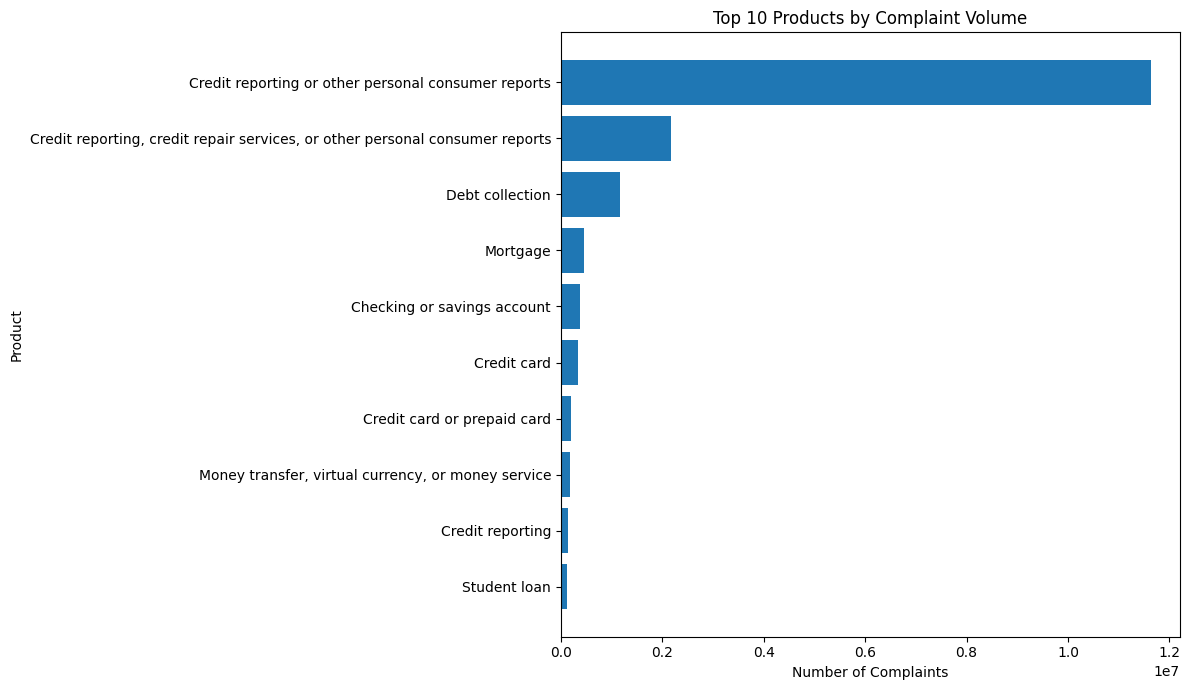

In [14]:
import matplotlib.pyplot as plt

top_products = product_summary.head(10).sort_values(
    "Complaint Count"
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_products.index,
    top_products["Complaint Count"]
)

plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.title("Top 10 Products by Complaint Volume")

plt.tight_layout()
plt.show()

# Deep EDA — Product Trends Over Time

In [15]:
# ow has complaint volume for different products changed from 2014 to 2026?
product_year_counts = {}

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Date received", "Product"]
    )

    chunk["Date received"] = pd.to_datetime(
        chunk["Date received"],
        errors="coerce"
    )

    chunk["Year"] = chunk["Date received"].dt.year

    counts = (
        chunk.groupby(["Year", "Product"])
        .size()
    )

    for (year, product), count in counts.items():
        key = (year, product)

        product_year_counts[key] = (
            product_year_counts.get(key, 0) + count
        )

product_year = (
    pd.Series(product_year_counts)
    .rename("Complaint Count")
    .reset_index()
)

product_year.columns = [
    "Year",
    "Product",
    "Complaint Count"
]

product_year.head()

,Year,Product,Complaint Count
0,2014,Money transfers,1169
1,2015,Credit card,17297
2,2015,Debt collection,39565
3,2015,Money transfers,1619
4,2017,Mortgage,30555


In [16]:
top_5_products = (
    product_counts
    .head(5)
    .index
    .tolist()
)

top_5_products
top_product_year = product_year[
    product_year["Product"].isin(top_5_products)
]

top_product_year = (
    top_product_year
    .pivot(
        index="Year",
        columns="Product",
        values="Complaint Count"
    )
    .fillna(0)
)

In [17]:
top_5_products


['Credit reporting or other personal consumer reports',
 'Credit reporting, credit repair services, or other personal consumer reports',
 'Debt collection',
 'Mortgage',
 'Checking or savings account']

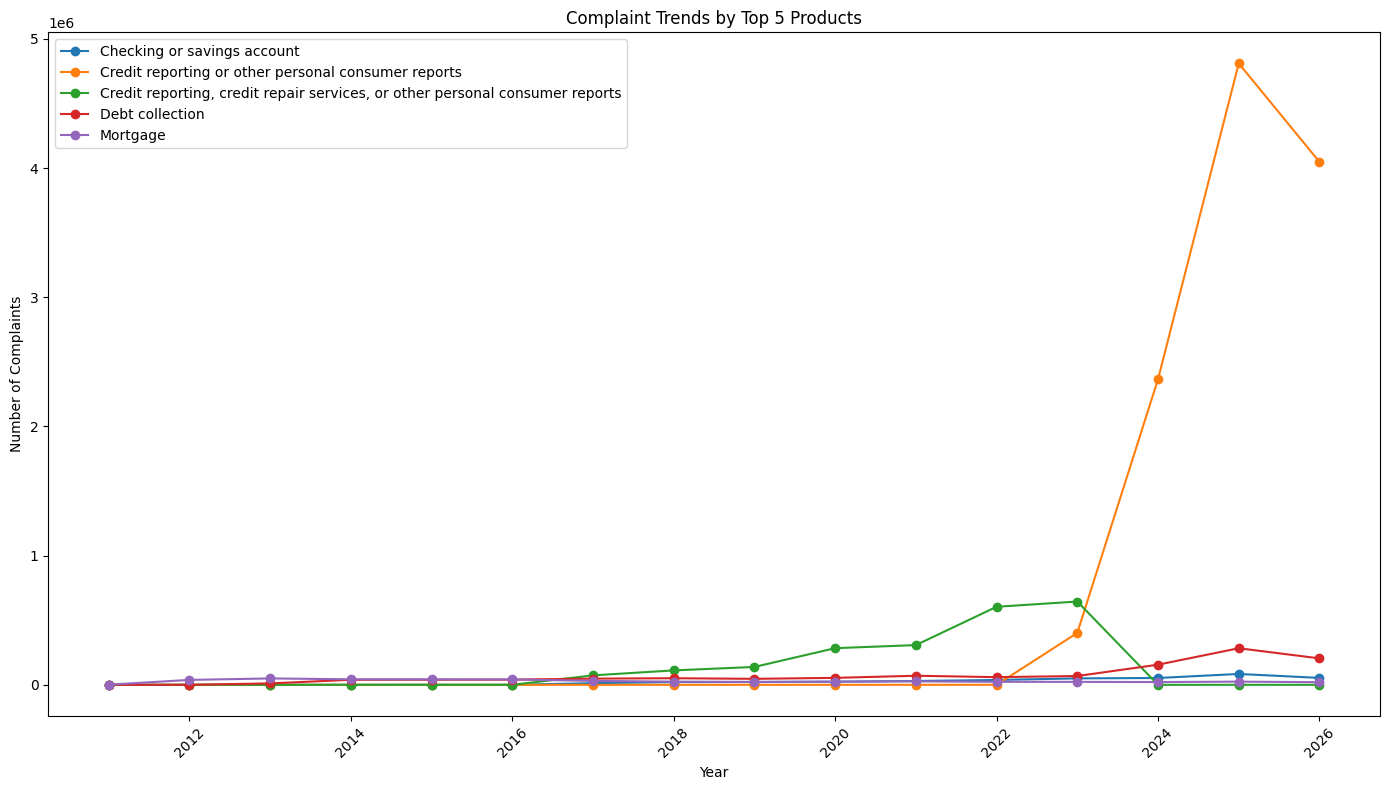

In [18]:
plt.figure(figsize=(14, 8))

for product in top_product_year.columns:
    plt.plot(
        top_product_year.index,
        top_product_year[product],
        marker="o",
        label=product
    )

plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.title("Complaint Trends by Top 5 Products")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
## Deep EDA — Monthly Complaint Trend

In [20]:
monthly_counts = {}

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Date received"]
    )

    chunk["Date received"] = pd.to_datetime(
        chunk["Date received"],
        errors="coerce"
    )

    chunk["Month"] = chunk["Date received"].dt.to_period("M")

    counts = chunk["Month"].value_counts()

    for month, count in counts.items():
        monthly_counts[month] = (
            monthly_counts.get(month, 0) + count
        )

monthly_counts = (
    pd.Series(monthly_counts)
    .sort_index()
)

monthly_counts.head()

2011-12    2536
2012-01    3230
2012-02    3509
2012-03    6229
2012-04    5703
Freq: M, dtype: int64

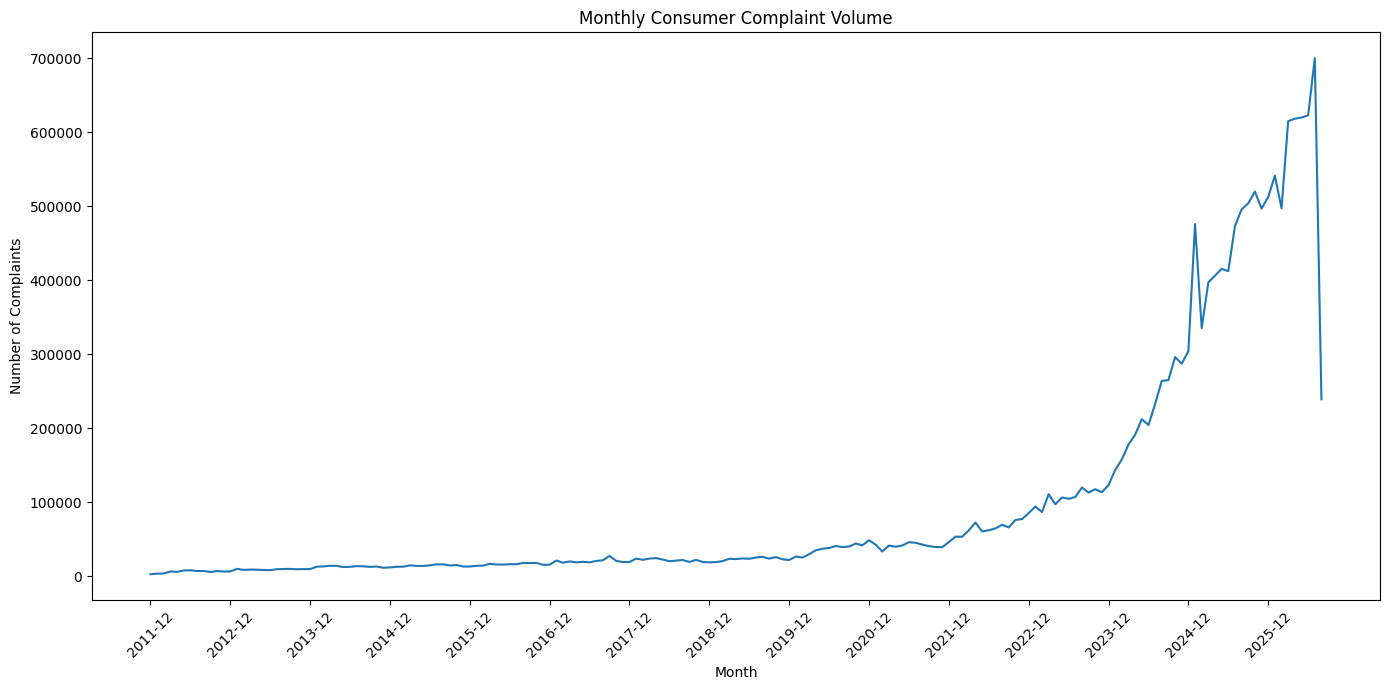

In [21]:
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_counts.index.astype(str),
    monthly_counts.values
)

plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.title("Monthly Consumer Complaint Volume")

plt.xticks(
    range(0, len(monthly_counts), 12),
    monthly_counts.index.astype(str)[::12],
    rotation=45
)

plt.tight_layout()
plt.show()

In [22]:
print("First 10 months:")
print(monthly_counts.index[:10])

print("\nLast 10 months:")
print(monthly_counts.index[-10:])

print("\nEarliest month:", monthly_counts.index.min())
print("Latest month:", monthly_counts.index.max())

First 10 months:
PeriodIndex(['2011-12', '2012-01', '2012-02', '2012-03', '2012-04', '2012-05',
             '2012-06', '2012-07', '2012-08', '2012-09'],
            dtype='period[M]')

Last 10 months:
PeriodIndex(['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04',
             '2026-05', '2026-06', '2026-07', '2026-08'],
            dtype='period[M]')

Earliest month: 2011-12
Latest month: 2026-08


In [23]:
year_counts = {}

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Date received"]
    )

    dates = pd.to_datetime(
        chunk["Date received"],
        errors="coerce"
    )

    counts = dates.dt.year.value_counts()

    for year, count in counts.items():
        year_counts[year] = (
            year_counts.get(year, 0) + count
        )

year_counts = (
    pd.Series(year_counts)
    .sort_index()
)

year_counts

2011       2536
2012      72368
2013     108214
2014     152909
2015     168273
2016     191292
2017     242745
2018     257131
2019     277240
2020     444213
2021     495939
2022     800245
2023    1292049
2024    2734269
2025    5442976
2026    4453068
dtype: int64

In [24]:
# Why did complaint volume increase so dramatically after 2022?

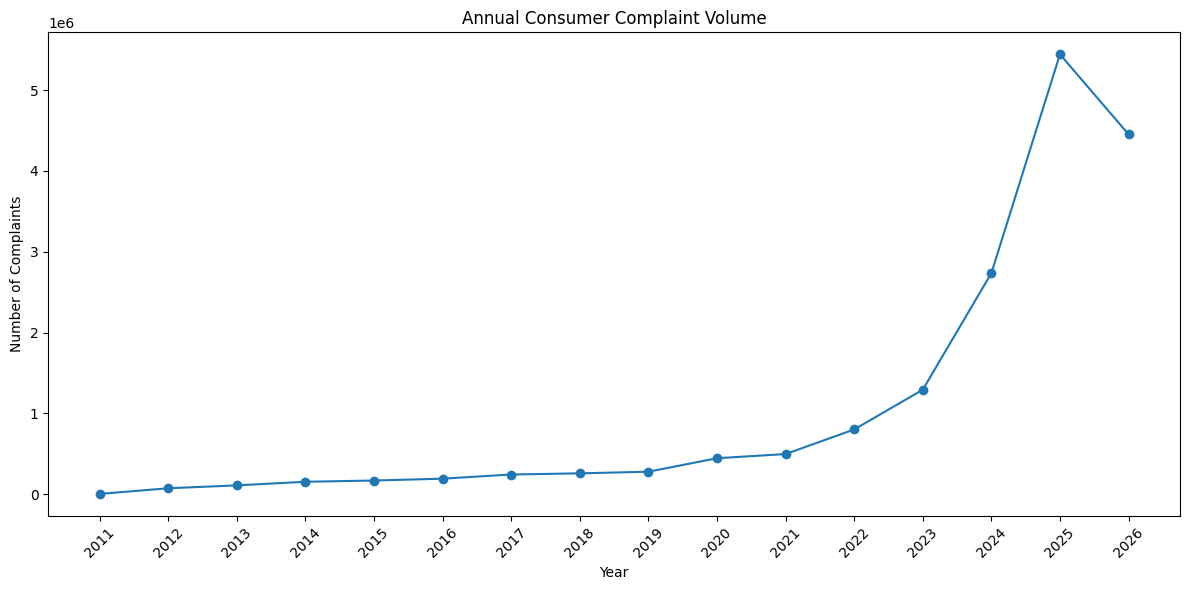

In [25]:
annual_counts = year_counts.copy()

plt.figure(figsize=(12, 6))

plt.plot(
    annual_counts.index,
    annual_counts.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.title("Annual Consumer Complaint Volume")

plt.xticks(annual_counts.index, rotation=45)

plt.tight_layout()
plt.show()

In [26]:
# Why did complaint volume explode after 2022, and how much of that increase is driven by credit-reporting categories?

In [27]:
 # Deep EDA — Product Composition Over Time

In [28]:
# Calculate total complaints for each year
year_totals = (
    product_year
    .groupby("Year")["Complaint Count"]
    .sum()
)

# Calculate percentage share of each product within its year
product_year["Year Total"] = product_year["Year"].map(year_totals)

product_year["Percentage"] = (
    product_year["Complaint Count"]
    / product_year["Year Total"]
    * 100
).round(2)

product_year.head()

,Year,Product,Complaint Count,Year Total,Percentage
0,2014,Money transfers,1169,152909,0.76
1,2015,Credit card,17297,168273,10.28
2,2015,Debt collection,39565,168273,23.51
3,2015,Money transfers,1619,168273,0.96
4,2017,Mortgage,30555,242745,12.59


In [29]:
top_product_year_share = product_year[
    product_year["Product"].isin(top_5_products)
].copy()

top_product_year_share = (
    top_product_year_share
    .pivot(
        index="Year",
        columns="Product",
        values="Percentage"
    )
    .fillna(0)
)

top_product_year_share

Product,Checking or savings account,Credit reporting or other personal consumer reports,"Credit reporting, credit repair services, or other personal consumer reports",Debt collection,Mortgage
Year,,,,,
2011,0.00,0.00,0.00,0.00,50.32
2012,0.00,0.00,0.00,0.00,52.66
2013,0.00,0.00,0.00,10.23,45.65
2014,0.00,0.00,0.00,25.53,28.08
2015,0.00,0.00,0.00,23.51,25.15
2016,0.00,0.00,0.00,21.09,21.67
2017,5.26,0.00,30.22,19.71,12.59
2018,8.25,0.00,43.40,19.86,9.55
2019,7.84,0.00,49.98,16.71,8.19


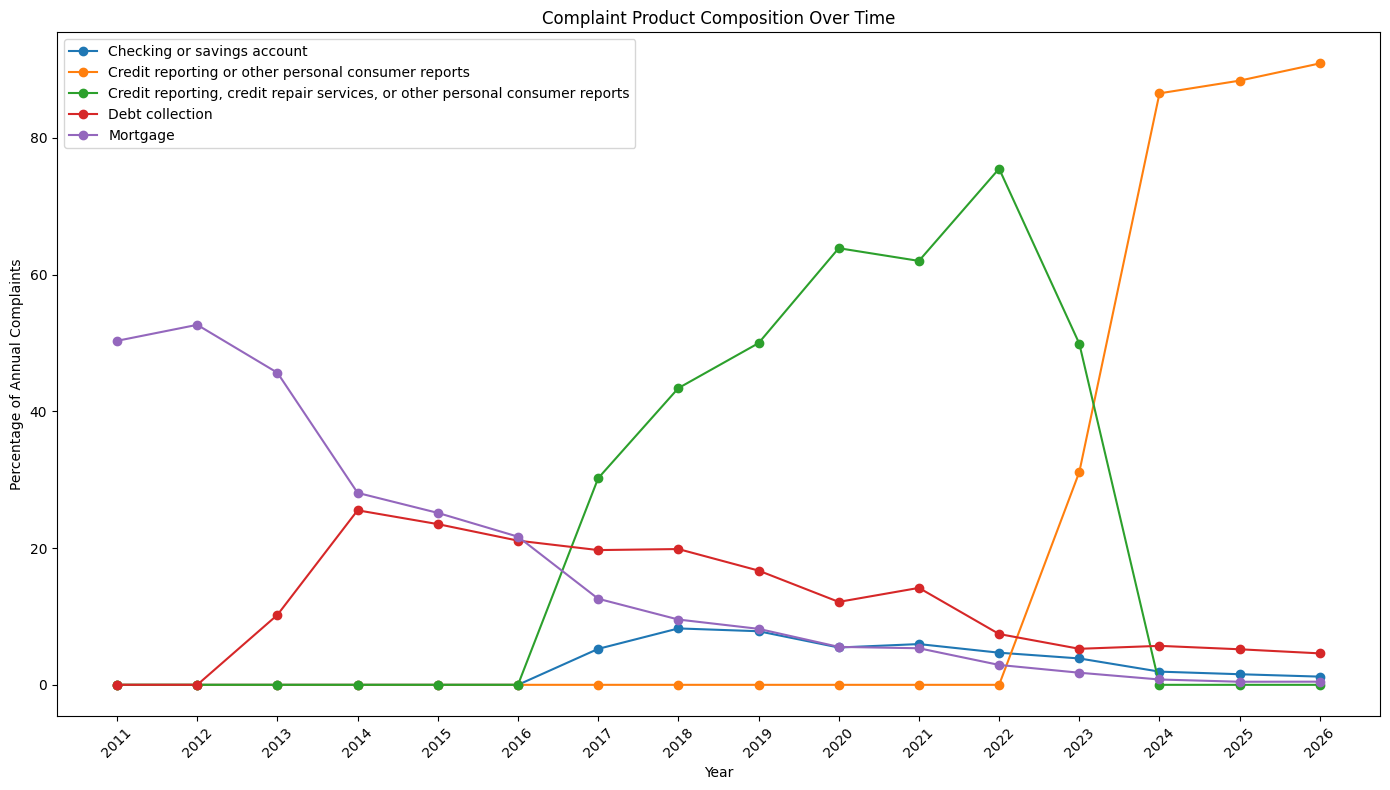

In [30]:
plt.figure(figsize=(14, 8))

for product in top_product_year_share.columns:
    plt.plot(
        top_product_year_share.index,
        top_product_year_share[product],
        marker="o",
        label=product
    )

plt.xlabel("Year")
plt.ylabel("Percentage of Annual Complaints")
plt.title("Complaint Product Composition Over Time")
plt.legend()

plt.xticks(
    top_product_year_share.index,
    rotation=45
)

plt.tight_layout()
plt.show()

In [31]:
# The dataset exhibits a substantial temporal shift in product categorization, 
# with credit-reporting-related complaints becoming increasingly dominant, particularly after 2023.

In [32]:
# ## Deep EDA — Product Label Transition Analysis

In [33]:
product_year_presence = (
    product_year
    .assign(Present=1)
    .pivot_table(
        index="Product",
        columns="Year",
        values="Present",
        aggfunc="max",
        fill_value=0
    )
)

product_year_presence

Year,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Product,,,,,,,,,,,,,,,,
Bank account or service,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0
Checking or savings account,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1
Consumer Loan,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0
Credit card,1,1,1,1,1,1,1,0,0,0,0,0,1,1,1,1
Credit card or prepaid card,0,0,0,0,0,0,1,1,1,1,1,1,1,0,0,0
Credit reporting,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0
Credit reporting or other personal consumer reports,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1
"Credit reporting, credit repair services, or other personal consumer reports",0,0,0,0,0,0,1,1,1,1,1,1,1,0,0,0
Debt collection,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [34]:
product_lifecycle = []

for product in product_year_presence.index:

    years_present = product_year_presence.columns[
        product_year_presence.loc[product] == 1
    ]

    product_lifecycle.append({
        "Product": product,
        "First Year": years_present.min(),
        "Last Year": years_present.max(),
        "Years Present": len(years_present)
    })

product_lifecycle = (
    pd.DataFrame(product_lifecycle)
    .sort_values("First Year")
)

product_lifecycle

,Product,First Year,Last Year,Years Present
3,Credit card,2011,2026,11
12,Mortgage,2011,2026,16
0,Bank account or service,2012,2017,6
18,Student loan,2012,2026,15
2,Consumer Loan,2012,2017,6
5,Credit reporting,2012,2017,6
14,Payday loan,2013,2017,5
8,Debt collection,2013,2026,14
11,Money transfers,2013,2017,5
17,Prepaid card,2014,2026,8


In [35]:
product_lifecycle[
    product_lifecycle["Product"].str.contains(
        "Credit reporting",
        case=False,
        na=False
    )
]

,Product,First Year,Last Year,Years Present
5,Credit reporting,2012,2017,6
7,"Credit reporting, credit repair services, or o...",2017,2023,7
6,Credit reporting or other personal consumer re...,2023,2026,4


In [36]:
# ## Deep EDA — Complaint Distribution by Issue

In [37]:
issue_counts = {}

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Issue"]
    )

    counts = chunk["Issue"].value_counts(dropna=False)

    for issue, count in counts.items():
        issue_counts[issue] = (
            issue_counts.get(issue, 0) + count
        )

issue_counts = (
    pd.Series(issue_counts)
    .sort_values(ascending=False)
)

issue_summary = pd.DataFrame({
    "Complaint Count": issue_counts,
    "Percentage": (
        issue_counts / total_rows * 100
    ).round(2)
})

In [38]:
issue_summary.head(15)

,Complaint Count,Percentage
Incorrect information on your report,7666247,44.74
Improper use of your report,3287612,19.19
Problem with a company's investigation into an existing problem,2195370,12.81
Problem with a credit reporting company's investigation into an existing problem,589318,3.44
Attempts to collect debt not owed,470545,2.75
Written notification about debt,226975,1.32
Managing an account,226446,1.32
Took or threatened to take negative or legal action,144037,0.84
False statements or representation,118926,0.69
"Loan modification,collection,foreclosure",112294,0.66


In [39]:
## Deep EDA — Product × Issue Analysis

In [40]:
product_issue_counts = {}

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Product", "Issue"]
    )

    counts = (
        chunk
        .groupby(["Product", "Issue"])
        .size()
    )

    for (product, issue), count in counts.items():
        key = (product, issue)

        product_issue_counts[key] = (
            product_issue_counts.get(key, 0) + count
        )

product_issue = (
    pd.Series(product_issue_counts)
    .rename("Complaint Count")
    .reset_index()
)

product_issue.columns = [
    "Product",
    "Issue",
    "Complaint Count"
]

product_issue = product_issue.sort_values(
    "Complaint Count",
    ascending=False
)

product_issue.head(20)

,Product,Issue,Complaint Count
30,Credit reporting or other personal consumer re...,Incorrect information on your report,6584409
29,Credit reporting or other personal consumer re...,Improper use of your report,2767859
32,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,2163574
36,"Credit reporting, credit repair services, or o...",Incorrect information on your report,1014586
37,"Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,577518
35,"Credit reporting, credit repair services, or o...",Improper use of your report,510337
38,Debt collection,Attempts to collect debt not owed,470545
45,Debt collection,Written notification about debt,226975
4,Checking or savings account,Managing an account,226445
44,Debt collection,Took or threatened to take negative or legal a...,144037


In [41]:
# ## Deep EDA — Sub-Issue Analysis

In [42]:
subissue_counts = {}

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Sub-issue"]
    )

    counts = chunk["Sub-issue"].value_counts(dropna=False)

    for subissue, count in counts.items():
        subissue_counts[subissue] = (
            subissue_counts.get(subissue, 0) + count
        )

subissue_counts = (
    pd.Series(subissue_counts)
    .sort_values(ascending=False)
)

subissue_summary = pd.DataFrame({
    "Complaint Count": subissue_counts,
    "Percentage": (
        subissue_counts / total_rows * 100
    ).round(2)
})

subissue_summary.head(20)

,Complaint Count,Percentage
Information belongs to someone else,5014860,29.27
Reporting company used your report improperly,2444585,14.27
Their investigation did not fix an error on your report,1516110,8.85
Account information incorrect,1310890,7.65
Investigation took more than 30 days,935267,5.46
NaN,927721,5.41
Credit inquiries on your report that you don't recognize,826786,4.82
Account status incorrect,763927,4.46
Personal information incorrect,339992,1.98
Debt is not yours,263520,1.54


In [43]:
## Deep EDA — Product × Issue × Sub-Issue

In [44]:
product_issue_subissue_counts = {}

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Product", "Issue", "Sub-issue"]
    )

    counts = (
        chunk
        .groupby(
            ["Product", "Issue", "Sub-issue"],
            dropna=False
        )
        .size()
    )

    for (product, issue, subissue), count in counts.items():
        key = (product, issue, subissue)

        product_issue_subissue_counts[key] = (
            product_issue_subissue_counts.get(key, 0) + count
        )

product_issue_subissue = (
    pd.Series(product_issue_subissue_counts)
    .rename("Complaint Count")
    .reset_index()
)

product_issue_subissue = (
    product_issue_subissue
    .sort_values("Complaint Count", ascending=False)
)

product_issue_subissue.head(20)

,level_0,level_1,level_2,Complaint Count
108,Credit reporting or other personal consumer re...,Incorrect information on your report,Information belongs to someone else,4332072
105,Credit reporting or other personal consumer re...,Improper use of your report,Reporting company used your report improperly,2096765
106,Credit reporting or other personal consumer re...,Incorrect information on your report,Account information incorrect,1185039
123,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,1170863
121,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,Investigation took more than 30 days,801573
131,"Credit reporting, credit repair services, or o...",Incorrect information on your report,Information belongs to someone else,673652
102,Credit reporting or other personal consumer re...,Improper use of your report,Credit inquiries on your report that you don't...,658472
107,Credit reporting or other personal consumer re...,Incorrect information on your report,Account status incorrect,616975
128,"Credit reporting, credit repair services, or o...",Improper use of your report,Reporting company used your report improperly,341732
132,"Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,328301


In [45]:
# Understand the hierarchy

In [46]:
product_issue_subissue.shape

(5327, 4)

In [47]:
print(product_issue_subissue.columns.tolist())

['level_0', 'level_1', 'level_2', 'Complaint Count']


In [48]:
product_issue_subissue = product_issue_subissue.rename(
    columns={
        "level_0": "Product",
        "level_1": "Issue",
        "level_2": "Sub-issue"
    }
)

In [49]:
print("Products:", product_issue_subissue["Product"].nunique())
print("Issues:", product_issue_subissue["Issue"].nunique())
print("Sub-issues:", product_issue_subissue["Sub-issue"].nunique())

Products: 21
Issues: 178
Sub-issues: 272


In [50]:
product_issue_subissue.head(20)

,Product,Issue,Sub-issue,Complaint Count
108,Credit reporting or other personal consumer re...,Incorrect information on your report,Information belongs to someone else,4332072
105,Credit reporting or other personal consumer re...,Improper use of your report,Reporting company used your report improperly,2096765
106,Credit reporting or other personal consumer re...,Incorrect information on your report,Account information incorrect,1185039
123,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,1170863
121,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,Investigation took more than 30 days,801573
131,"Credit reporting, credit repair services, or o...",Incorrect information on your report,Information belongs to someone else,673652
102,Credit reporting or other personal consumer re...,Improper use of your report,Credit inquiries on your report that you don't...,658472
107,Credit reporting or other personal consumer re...,Incorrect information on your report,Account status incorrect,616975
128,"Credit reporting, credit repair services, or o...",Improper use of your report,Reporting company used your report improperly,341732
132,"Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,328301


In [51]:
product_summary = (
    product_issue_subissue
    .groupby("Product", dropna=False)["Complaint Count"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_summary

,Product,Complaint Count
0,Credit reporting or other personal consumer re...,11625979
1,"Credit reporting, credit repair services, or o...",2163770
2,Debt collection,1170800
3,Mortgage,457183
4,Checking or savings account,387543
5,Credit card,334750
6,Credit card or prepaid card,206356
7,"Money transfer, virtual currency, or money ser...",187639
8,Credit reporting,140426
9,Student loan,131922


In [52]:
total_complaints = product_summary["Complaint Count"].sum()

product_summary["Percentage"] = (
    product_summary["Complaint Count"]
    / total_complaints
    * 100
)

product_summary

,Product,Complaint Count,Percentage
0,Credit reporting or other personal consumer re...,11625979,67.847459
1,"Credit reporting, credit repair services, or o...",2163770,12.627435
2,Debt collection,1170800,6.832612
3,Mortgage,457183,2.668051
4,Checking or savings account,387543,2.261642
5,Credit card,334750,1.953550
6,Credit card or prepaid card,206356,1.204262
7,"Money transfer, virtual currency, or money ser...",187639,1.095033
8,Credit reporting,140426,0.819505
9,Student loan,131922,0.769877


In [53]:
product_summary.head(10)

,Product,Complaint Count,Percentage
0,Credit reporting or other personal consumer re...,11625979,67.847459
1,"Credit reporting, credit repair services, or o...",2163770,12.627435
2,Debt collection,1170800,6.832612
3,Mortgage,457183,2.668051
4,Checking or savings account,387543,2.261642
5,Credit card,334750,1.953550
6,Credit card or prepaid card,206356,1.204262
7,"Money transfer, virtual currency, or money ser...",187639,1.095033
8,Credit reporting,140426,0.819505
9,Student loan,131922,0.769877


In [54]:
# # Statistical Testing

In [55]:
product_issue_table = pd.pivot_table(
    product_issue_subissue,
    index="Product",
    columns="Issue",
    values="Complaint Count",
    aggfunc="sum",
    fill_value=0
)

In [56]:
product_issue_subissue

,Product,Issue,Sub-issue,Complaint Count
108,Credit reporting or other personal consumer re...,Incorrect information on your report,Information belongs to someone else,4332072
105,Credit reporting or other personal consumer re...,Improper use of your report,Reporting company used your report improperly,2096765
106,Credit reporting or other personal consumer re...,Incorrect information on your report,Account information incorrect,1185039
123,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,1170863
121,Credit reporting or other personal consumer re...,Problem with a company's investigation into an...,Investigation took more than 30 days,801573
...,...,...,...,...
4836,Checking or savings account,Managing an account,NaN,1
4839,Credit card or prepaid card,Problem with fraud alerts or security freezes,NaN,1
4057,Debt or credit management,Charged upfront or unexpected fees,NaN,1
2891,"Payday loan, title loan, personal loan, or adv...",Confusing or missing disclosures,NaN,1


In [57]:
product_issue_table.shape

(21, 178)

In [58]:
product_issue_table.head()

Issue,APR or interest rate,"Account opening, closing, or management",Account terms and changes,Adding money,Advertising,Advertising and marketing,"Advertising and marketing, including promotional offers","Advertising, marketing or disclosures",Application processing delay,"Application, originator, mortgage broker",...,Unexpected or other fees,Unexpected/Other fees,Unsolicited issuance of credit card,Using a debit or ATM card,Vehicle was damaged or destroyed the vehicle,Vehicle was repossessed or sold the vehicle,"Was approved for a loan, but didn't receive money","Was approved for a loan, but didn't receive the money",Written notification about debt,Wrong amount charged or received
Product,,,,,,,,,,,,,,,,,,,,,
Bank account or service,0,37959,0,0,0,0,0,0,0,0,...,0,0,0,6144,0,0,0,0,0,0
Checking or savings account,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Consumer Loan,0,0,484,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Credit card,5506,0,0,0,0,2926,9196,0,540,0,...,0,0,1853,0,0,0,0,0,0,0
Credit card or prepaid card,0,0,0,0,352,0,9706,0,0,0,...,2883,0,0,0,0,0,0,0,0,0


In [59]:
# Run the Chi-square test
# for product and issue 

In [60]:
from scipy.stats import chi2_contingency

In [61]:
chi2, p_value, dof, expected = chi2_contingency(
    product_issue_table
)

In [62]:
print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 224768063.70486462
p-value: 0.0
Degrees of freedom: 3540


In [63]:
# Statistical conclusion

# There is very strong statistical evidence that Product and Issue are associated

In [64]:

import numpy as np

n = product_issue_table.to_numpy().sum()

r, k = product_issue_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(k - 1, r - 1))
)

print("Total observations:", n)
print("Cramér's V:", cramers_v)

Total observations: 17135461
Cramér's V: 0.8098496668847176


In [65]:
# Stats test for issue and sub-issue association

In [66]:
issue_subissue_table = pd.pivot_table(
    product_issue_subissue,
    index="Issue",
    columns="Sub-issue",
    values="Complaint Count",
    aggfunc="sum",
    fill_value=0
)

issue_subissue_table.shape

(61, 272)

In [67]:
print("Issues in original table:",
      product_issue_subissue["Issue"].nunique())

print("Issues in contingency table:",
      issue_subissue_table.shape[0])

print("Sub-issues in original table:",
      product_issue_subissue["Sub-issue"].nunique())

print("Sub-issues in contingency table:",
      issue_subissue_table.shape[1])

Issues in original table: 178
Issues in contingency table: 61
Sub-issues in original table: 272
Sub-issues in contingency table: 272


In [68]:
# Step 1 — Check whether those missing Issues are NaN

In [69]:
print(
    product_issue_subissue["Issue"].isna().sum()
)

print(
    product_issue_subissue["Product"].isna().sum()
)

print(
    product_issue_subissue["Sub-issue"].isna().sum()
)

3
0
4702


In [70]:
print(
    product_issue_subissue[
        product_issue_subissue["Issue"].isna()
    ].head(20)
)

                                                Product Issue Sub-issue  \
1709                        Checking or savings account   NaN       NaN   
1764  Credit reporting or other personal consumer re...   NaN       NaN   
1813                        Checking or savings account   NaN       NaN   

      Complaint Count  
1709                4  
1764                1  
1813                1  


In [71]:
print(
    product_issue_subissue["Issue"]
    .dropna()
    .unique()
)

['Incorrect information on your report' 'Improper use of your report'
 "Problem with a company's investigation into an existing problem"
 "Problem with a credit reporting company's investigation into an existing problem"
 'Attempts to collect debt not owed' 'Written notification about debt'
 'Took or threatened to take negative or legal action'
 'False statements or representation' 'Managing an account'
 'Problem with a purchase shown on your statement' 'Communication tactics'
 'Incorrect information on credit report'
 "Cont'd attempts collect debt not owed" 'Other transaction problem'
 'Problem with a lender or other company charging your account'
 'Loan modification,collection,foreclosure'
 'Unable to get your credit report or credit score'
 'Dealing with your lender or servicer' 'Closing an account'
 'Disclosure verification of debt'
 'Problem caused by your funds being low'
 'Loan servicing, payments, escrow account' 'Getting a credit card'
 'Managing the loan or lease' 'Problem wh

In [72]:
print(
    issue_subissue_table.index.tolist()
)

['Advertising', 'Advertising and marketing, including promotional offers', 'Applying for a mortgage or refinancing an existing mortgage', 'Attempts to collect debt not owed', "Can't repay my loan", 'Closing an account', 'Closing on a mortgage', 'Closing your account', 'Communication tactics', "Cont'd attempts collect debt not owed", 'Credit monitoring or identity protection', 'Credit monitoring or identity theft protection services', "Credit reporting company's investigation", 'Dealing with my lender or servicer', 'Dealing with your lender or servicer', 'Disclosure verification of debt', 'Electronic communications', 'False statements or representation', 'Fees or interest', 'Getting a credit card', 'Getting a loan', 'Getting a loan or lease', 'Identity theft protection or other monitoring services', 'Improper contact or sharing of info', 'Improper use of my credit report', 'Improper use of your report', 'Incorrect information on credit report', 'Incorrect information on your report', 'I

In [73]:
# We will create a copy of this . to protect original eda 

In [74]:
stats_df = product_issue_subissue.copy()

In [75]:
stats_df["Issue"] = (
    stats_df["Issue"]
    .fillna("Unknown / Not Provided")
)

stats_df["Sub-issue"] = (
    stats_df["Sub-issue"]
    .fillna("Unknown / Not Provided")
)

In [76]:
print("Issues:", stats_df["Issue"].nunique())
print("Sub-issues:", stats_df["Sub-issue"].nunique())

Issues: 179
Sub-issues: 273


In [77]:
issue_subissue_table = pd.pivot_table(
    stats_df,
    index="Issue",
    columns="Sub-issue",
    values="Complaint Count",
    aggfunc="sum",
    fill_value=0
)

In [78]:
issue_subissue_table.shape

(179, 273)

In [79]:
from scipy.stats import chi2_contingency

chi2_is, p_value_is, dof_is, expected_is = chi2_contingency(
    issue_subissue_table
)

print("Chi-square statistic:", chi2_is)
print("p-value:", p_value_is)
print("Degrees of freedom:", dof_is)

Chi-square statistic: 867856039.8581316
p-value: 0.0
Degrees of freedom: 48416


In [80]:
n_is = issue_subissue_table.to_numpy().sum()

r_is, k_is = issue_subissue_table.shape

cramers_v_is = np.sqrt(
    chi2_is / (
        n_is * min(r_is - 1, k_is - 1)
    )
)

print("Total observations:", n_is)
print("Cramér's V:", cramers_v_is)

Total observations: 17135467
Cramér's V: 0.5334157950800433


In [81]:
# Product and sub-issue association

In [82]:
product_subissue_table = pd.pivot_table(
    stats_df,
    index="Product",
    columns="Sub-issue",
    values="Complaint Count",
    aggfunc="sum",
    fill_value=0
)

print(product_subissue_table.shape)

(21, 273)


In [83]:
from scipy.stats import chi2_contingency

chi2_ps, p_value_ps, dof_ps, expected_ps = chi2_contingency(
    product_subissue_table
)

print("Chi-square statistic:", chi2_ps)
print("p-value:", p_value_ps)
print("Degrees of freedom:", dof_ps)

Chi-square statistic: 115201381.17415518
p-value: 0.0
Degrees of freedom: 5440


In [84]:
n_ps = product_subissue_table.to_numpy().sum()

r_ps, k_ps = product_subissue_table.shape

cramers_v_ps = np.sqrt(
    chi2_ps / (
        n_ps * min(r_ps - 1, k_ps - 1)
    )
)

print("Total observations:", n_ps)
print("Cramér's V:", cramers_v_ps)


Total observations: 17135467
Cramér's V: 0.5797835280785121


## Statistical Testing — Hierarchical Associations

To statistically validate the relationships identified during exploratory
data analysis, Chi-square tests of independence were conducted between
Product, Issue, and Sub-issue.

### Hypotheses

For each test:

**H₀:** The two categorical variables are independent.

**H₁:** The two categorical variables are associated.

Because the dataset contains over 17 million complaints, statistical
significance alone is insufficient. Cramér's V was therefore used to
measure the strength of association.

### Results

| Relationship | Chi-square | df | p-value | Cramér's V |
|---|---:|---:|---:|---:|
| Product × Issue | 224,768,063.70 | 3,540 | ≈ 0 | 0.80985 |
| Issue × Sub-issue | 867,856,039.86 | 48,416 | ≈ 0 | 0.53342 |
| Product × Sub-issue | 115,201,381.17 | 544 | ≈ 0 | 0.57978 |

### Interpretation

All three relationships are statistically significant, with p-values
effectively equal to zero.

The strongest observed association is between Product and Issue
(Cramér's V = 0.80985), indicating that the type of financial product
is strongly associated with the type of complaint issue.

Issue and Sub-issue also show a strong association (Cramér's V = 0.53342),
while Product and Sub-issue show a strong association as well
(Cramér's V = 0.57978).

These results statistically validate the hierarchical patterns observed
during exploratory data analysis.

Because the dataset is extremely large, effect size was considered
alongside statistical significance rather than relying solely on
p-values.

# time Based Analysis 

In [85]:
monthly_counts = {}

for file in files:
    chunk = pd.read_csv(
        file,
        usecols=["Date received"]
    )

    chunk["Date received"] = pd.to_datetime(
        chunk["Date received"],
        errors="coerce"
    )

    monthly = (
        chunk["Date received"]
        .dt.to_period("M")
        .value_counts()
    )

    for month, count in monthly.items():
        monthly_counts[month] = (
            monthly_counts.get(month, 0) + count
        )

monthly_counts = pd.Series(monthly_counts).sort_index()

monthly_counts.head()

2011-12    2536
2012-01    3230
2012-02    3509
2012-03    6229
2012-04    5703
Freq: M, dtype: int64

In [86]:
full_month_range = pd.period_range(
    start="2011-12",
    end="2026-08",
    freq="M"
)

monthly_ts = (
    monthly_counts
    .reindex(full_month_range, fill_value=0)
    .rename("Complaint Count")
    .to_frame()
)

monthly_ts.index.name = "Month"

monthly_ts.head()

,Complaint Count
Month,
2011-12,2536
2012-01,3230
2012-02,3509
2012-03,6229
2012-04,5703


In [87]:
monthly_ts.head()

,Complaint Count
Month,
2011-12,2536
2012-01,3230
2012-02,3509
2012-03,6229
2012-04,5703


In [88]:
monthly_ts.tail(10)

,Complaint Count
Month,
2025-11,496658
2025-12,512476
2026-01,541266
2026-02,497103
2026-03,614913
2026-04,618226
2026-05,619753
2026-06,622729
2026-07,700078


In [89]:
print("Total months:", len(monthly_ts))
print("First month:", monthly_ts.index.min())
print("Last month:", monthly_ts.index.max())

Total months: 177
First month: 2011-12
Last month: 2026-08


In [90]:
missing_months = monthly_ts[
    monthly_ts["Complaint Count"] == 0
]

print("Months with zero complaints:", len(missing_months))
missing_months

Months with zero complaints: 0


,Complaint Count
Month,


In [91]:
print("monthly_ts shape:", monthly_ts.shape)
print("monthly_counts shape:", monthly_counts.shape)
print("monthly_counts first:", monthly_counts.index.min())
print("monthly_counts last:", monthly_counts.index.max())

monthly_ts shape: (177, 1)
monthly_counts shape: (177,)
monthly_counts first: 2011-12
monthly_counts last: 2026-08


In [92]:
monthly_ts

,Complaint Count
Month,
2011-12,2536
2012-01,3230
2012-02,3509
2012-03,6229
2012-04,5703
...,...
2026-04,618226
2026-05,619753
2026-06,622729


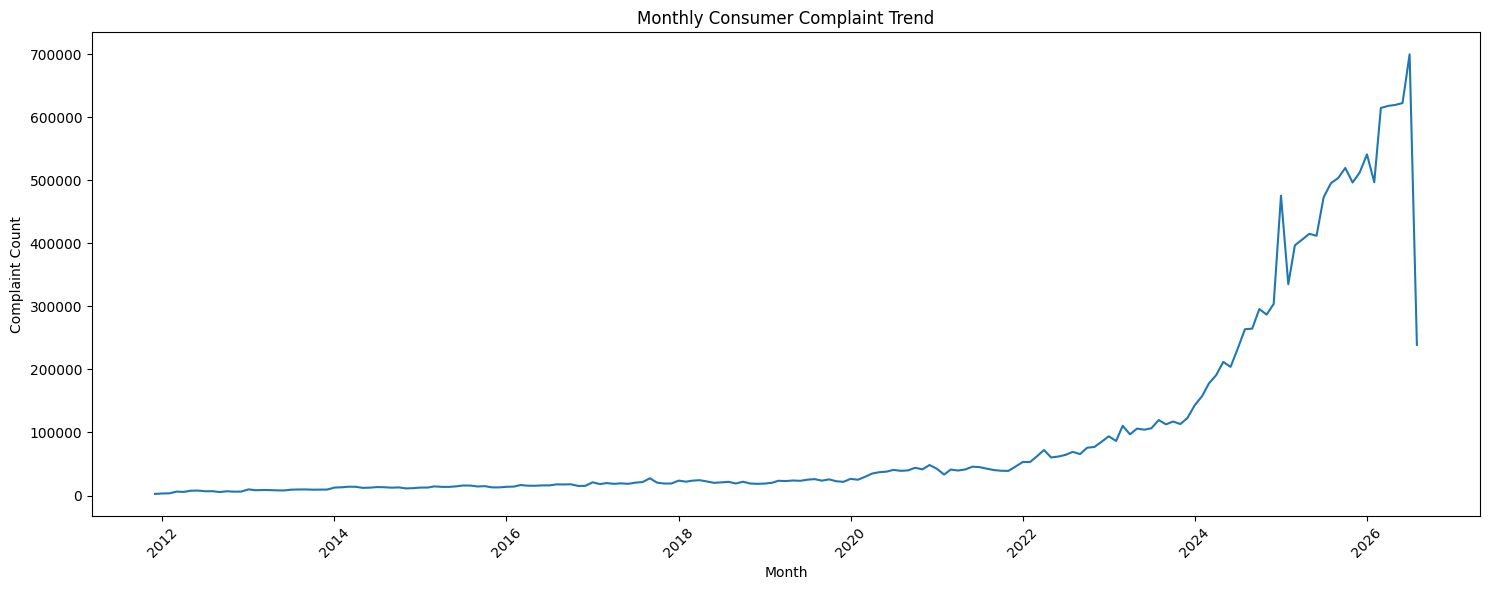

In [93]:
import matplotlib.pyplot as plt

monthly_plot = monthly_counts.copy()

monthly_plot.index = monthly_plot.index.to_timestamp()

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_plot.index,
    monthly_plot.values
)

plt.title("Monthly Consumer Complaint Trend")
plt.xlabel("Month")
plt.ylabel("Complaint Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

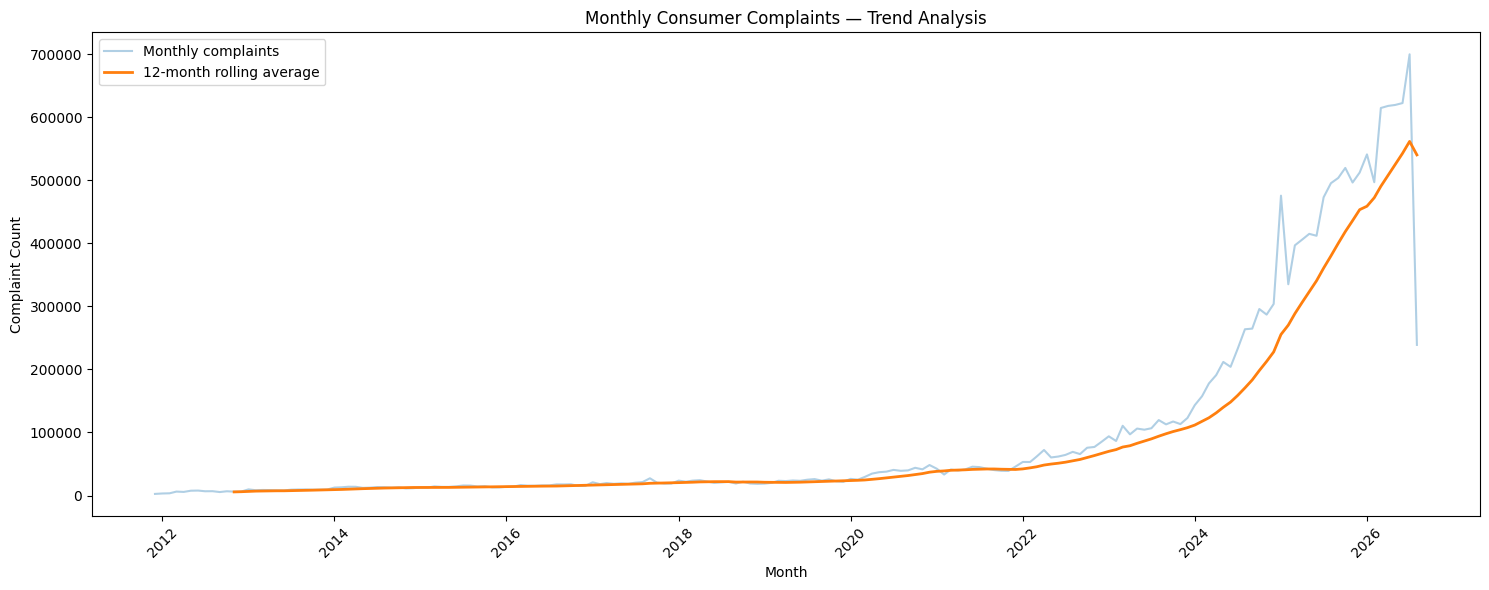

In [94]:
monthly_rolling = monthly_plot.rolling(12).mean()

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_plot.index,
    monthly_plot.values,
    alpha=0.35,
    label="Monthly complaints"
)

plt.plot(
    monthly_rolling.index,
    monthly_rolling.values,
    linewidth=2,
    label="12-month rolling average"
)

plt.title("Monthly Consumer Complaints — Trend Analysis")
plt.xlabel("Month")
plt.ylabel("Complaint Count")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\HIMANSHU VYAS\AppData\Local\Temp\ipykernel_15904\972868240.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


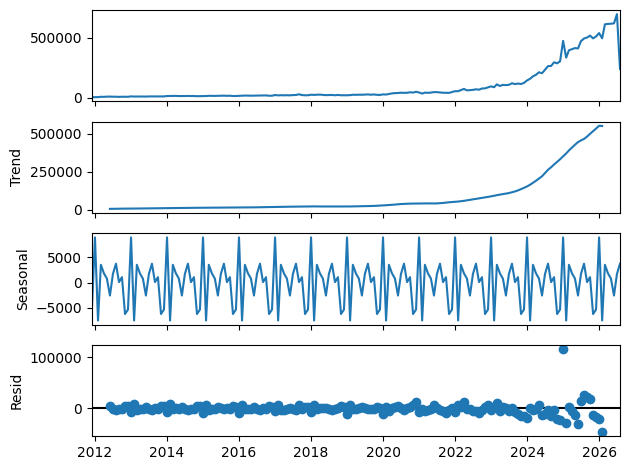

In [95]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_plot,
    model="additive",
    period=12
)

decomposition.plot()
plt.tight_layout()
plt.show()

In [96]:
monthly_ts

,Complaint Count
Month,
2011-12,2536
2012-01,3230
2012-02,3509
2012-03,6229
2012-04,5703
...,...
2026-04,618226
2026-05,619753
2026-06,622729


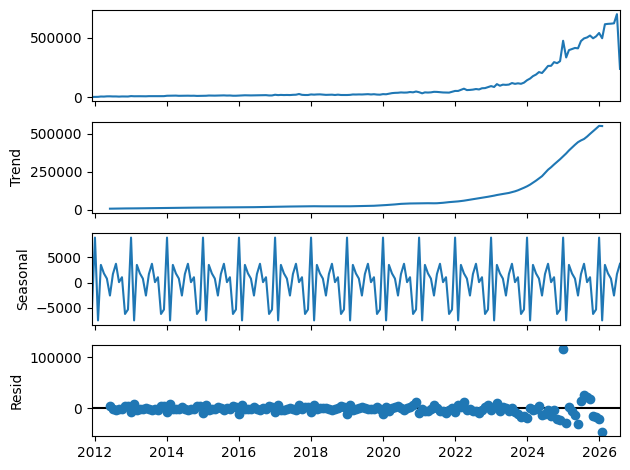

1     8962.515377
8     3748.113591
3     3527.127328
4     1824.217071
7     1693.726687
10    1070.122520
5      794.585661
9       88.881448
6    -2573.368552
12   -5356.642361
11   -6248.133433
2    -7531.145337
Name: seasonal, dtype: float64


In [97]:
ts = monthly_counts.copy()
ts.index = ts.index.to_timestamp()
ts = ts.asfreq("MS")
ts = ts.interpolate()  # safer than ffill if there are real gaps

result = seasonal_decompose(ts, model="additive", period=12)
result.plot()
plt.show()

seasonal_by_month = (
    result.seasonal.groupby(result.seasonal.index.month).mean()
    .sort_values(ascending=False)
)
print(seasonal_by_month)

In [98]:
ts = ts.iloc[:-1]  # drop likely-incomplete final month

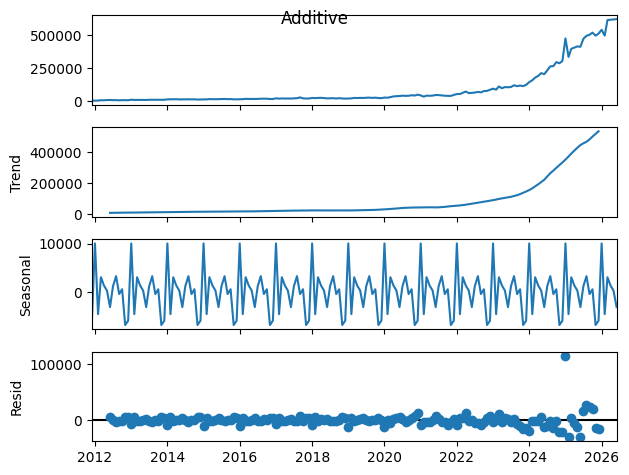

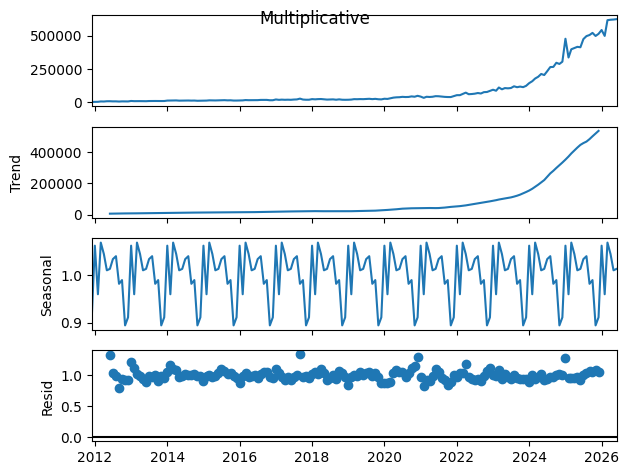

In [99]:
ts.index = ts.index.to_timestamp() if hasattr(ts.index, 'to_timestamp') else ts.index
ts = ts.asfreq("MS").interpolate()
ts = ts.iloc[:-1]  # drop incomplete last month

from statsmodels.tsa.seasonal import seasonal_decompose
result_add = seasonal_decompose(ts, model="additive", period=12)
result_mult = seasonal_decompose(ts, model="multiplicative", period=12)

result_add.plot()
plt.suptitle("Additive")
plt.show()

result_mult.plot()
plt.suptitle("Multiplicative")
plt.show()

In [100]:
print("Additive residual std:", result_add.resid.std())
print("Multiplicative residual std:", result_mult.resid.std())

Additive residual std: 11840.803705279011
Multiplicative residual std: 0.08240338455184644


In [101]:
seasonal_mult_by_month = (
    result_mult.seasonal.groupby(result_mult.seasonal.index.month).mean()
    .sort_values(ascending=False)
)
print(seasonal_mult_by_month)

3     1.067461
1     1.061044
4     1.043476
8     1.039012
7     1.032893
6     1.012425
5     1.009434
10    0.988961
9     0.981150
2     0.959258
12    0.910871
11    0.894016
Name: seasonal, dtype: float64


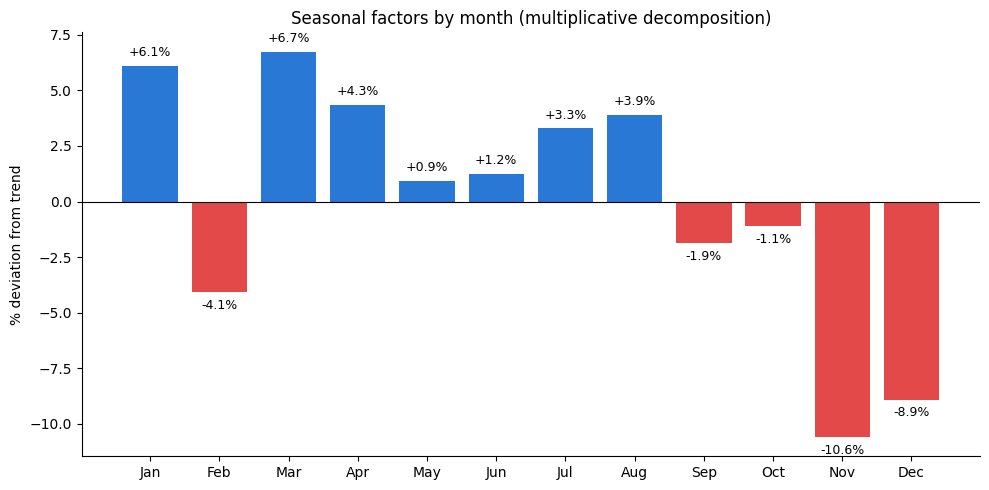

In [102]:
"""
Seasonal factor chart (multiplicative decomposition).
Run this in VS Code (or any Python environment) with:
    pip install matplotlib pandas
"""

import matplotlib.pyplot as plt

# --- Your multiplicative seasonal factors by month ---
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

seasonal_factor = [1.061044, 0.959258, 1.067461, 1.043476, 1.009434, 1.012425,
                    1.032893, 1.039012, 0.981150, 0.988961, 0.894016, 0.910871]

# Convert to % deviation from trend (1.0 = 0%)
pct_deviation = [(f - 1) * 100 for f in seasonal_factor]

# Color: blue if above trend, red if below trend
colors = ["#2a78d6" if v >= 0 else "#e34948" for v in pct_deviation]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(months, pct_deviation, color=colors, edgecolor="none")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("% deviation from trend")
ax.set_title("Seasonal factors by month (multiplicative decomposition)")

# Add value labels on top/bottom of each bar
for bar, val in zip(bars, pct_deviation):
    offset = 0.3 if val >= 0 else -0.3
    va = "bottom" if val >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
             f"{val:+.1f}%", ha="center", va=va, fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("seasonal_factors_by_month.png", dpi=150)
plt.show()

In [103]:
print(pd.read_csv(files[0], nrows=0).columns.tolist())

['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID', 'has_narrative', 'has_public_response']


In [104]:
# Monthly Trend Analysis by Product

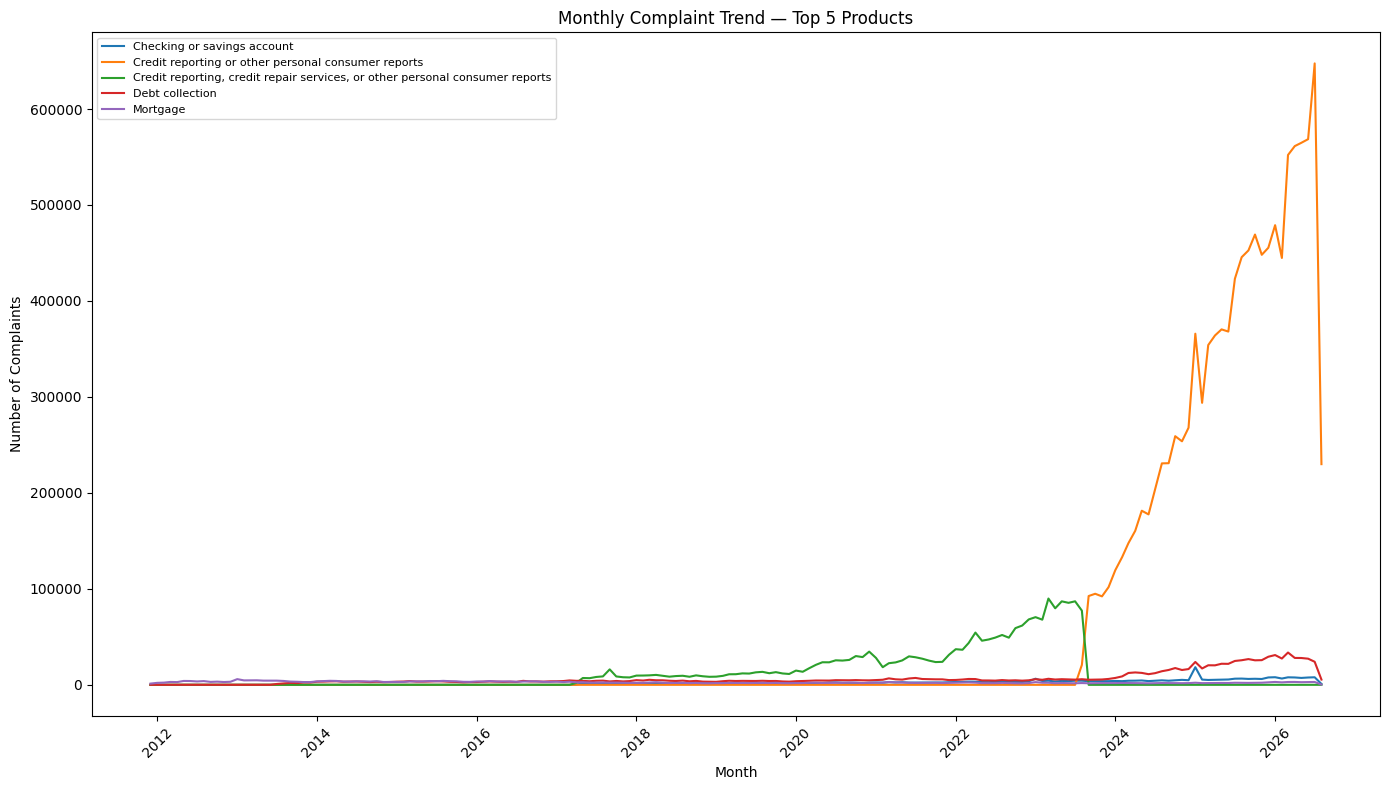


Trend direction (linear regression slope on monthly counts):

                                                                     Product  Slope (complaints/month)  R-squared  p-value  Direction
                         Credit reporting or other personal consumer reports                   1890.93      0.425 9.17e-23 Increasing
Credit reporting, credit repair services, or other personal consumer reports                    141.48      0.122 1.92e-06 Increasing
                                                             Debt collection                    106.17      0.559 5.75e-33 Increasing
                                                 Checking or savings account                     40.56      0.709 9.17e-49 Increasing
                                                                    Mortgage                    -11.56      0.469 8.23e-26 Decreasing


In [105]:
# --- Deep EDA — Monthly Product Trends (extends your existing yearly analysis) ---
# Assumes `files` and `top_5_products` already exist from earlier cells.

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: aggregate MONTHLY counts per product (finer-grained than product_year)
product_month_counts = {}

for file in files:
    chunk = pd.read_csv(file, usecols=["Date received", "Product"])
    chunk["Date received"] = pd.to_datetime(chunk["Date received"], errors="coerce")
    chunk["Month"] = chunk["Date received"].dt.to_period("M")

    counts = chunk.groupby(["Month", "Product"]).size()

    for (month, product), count in counts.items():
        key = (month, product)
        product_month_counts[key] = product_month_counts.get(key, 0) + count

product_month = (
    pd.Series(product_month_counts)
    .rename("Complaint Count")
    .reset_index()
)
product_month.columns = ["Month", "Product", "Complaint Count"]
product_month["Month"] = product_month["Month"].dt.to_timestamp()

# Step 2: pivot to Month x Product, restrict to top 5
top_product_month = (
    product_month[product_month["Product"].isin(top_5_products)]
    .pivot(index="Month", columns="Product", values="Complaint Count")
    .fillna(0)
    .sort_index()
)

# Step 3: plot monthly trend for top 5 products
plt.figure(figsize=(14, 8))
for product in top_product_month.columns:
    plt.plot(top_product_month.index, top_product_month[product], label=product, linewidth=1.5)

plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.title("Monthly Complaint Trend — Top 5 Products")
plt.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 4: quantify trend direction per product (simple linear regression slope)
print("\nTrend direction (linear regression slope on monthly counts):\n")
trend_results = []

for product in top_product_month.columns:
    y = top_product_month[product].values
    x = range(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    trend_results.append({
        "Product": product,
        "Slope (complaints/month)": round(slope, 2),
        "R-squared": round(r_value ** 2, 3),
        "p-value": f"{p_value:.2e}",
        "Direction": "Increasing" if slope > 0 and p_value < 0.05
                     else "Decreasing" if slope < 0 and p_value < 0.05
                     else "No significant trend"
    })

trend_df = pd.DataFrame(trend_results).sort_values("Slope (complaints/month)", ascending=False)
print(trend_df.to_string(index=False))

In [106]:
# Product_trend_merge

Top products after merging labels:

Product
Credit reporting (merged)                             13930175
Debt collection                                        1170800
Mortgage                                                457183
Checking or savings account                             387543
Credit card                                             334750
Credit card or prepaid card                             206356
Money transfer, virtual currency, or money service      187639
Student loan                                            131922
Vehicle loan or lease                                   100651
Bank account or service                                  86198
Name: Complaint Count, dtype: int64


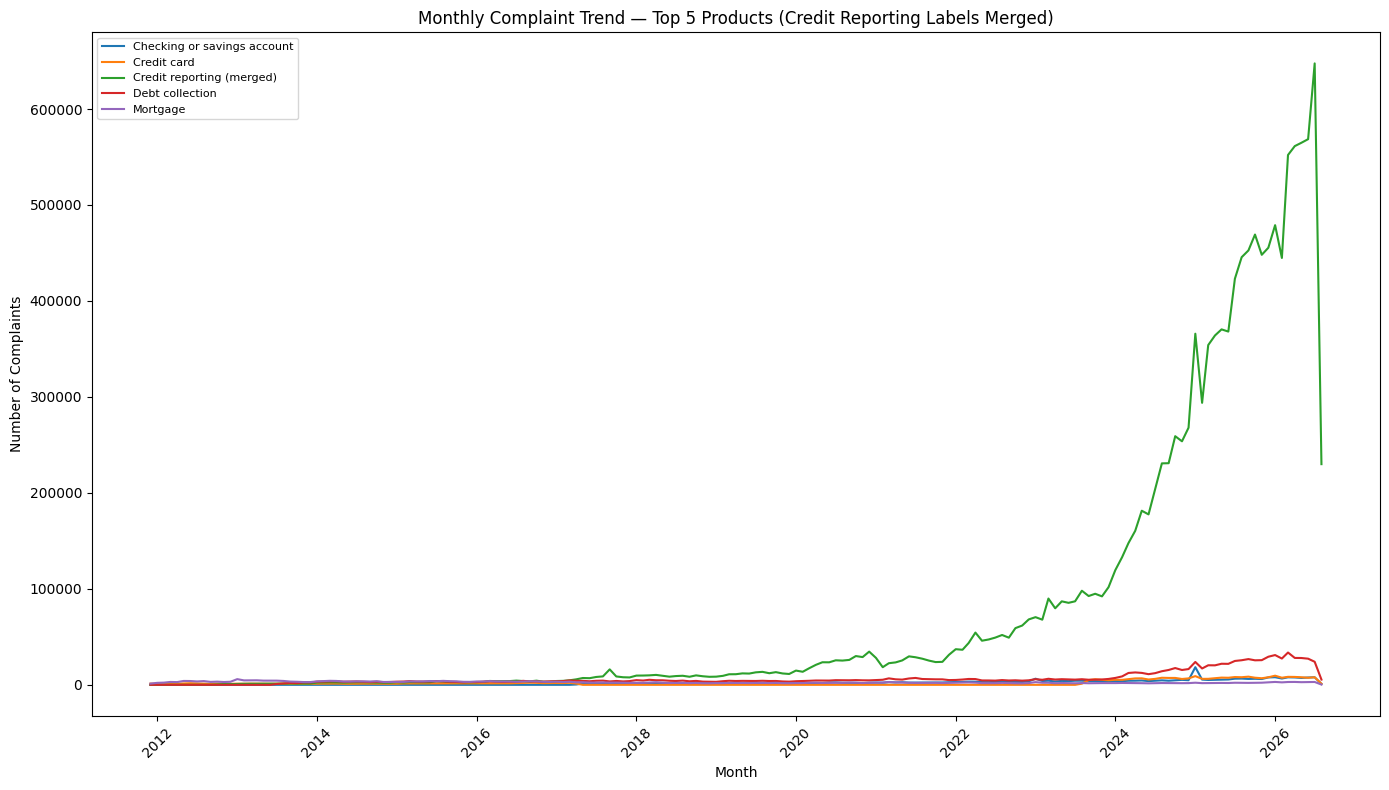


Trend direction (linear regression slope, corrected data):

                    Product  Slope (complaints/month)  R-squared  p-value  Direction
  Credit reporting (merged)                   2018.83      0.514 3.25e-29 Increasing
            Debt collection                    106.17      0.559 5.75e-33 Increasing
Checking or savings account                     40.56      0.709 9.17e-49 Increasing
                Credit card                     27.62      0.285 1.92e-14 Increasing
                   Mortgage                    -11.56      0.469 8.23e-26 Decreasing


In [107]:
# --- Fix: Merge the "Credit reporting" product label transition (2023 rename) ---
# Problem: CFPB renamed
#   "Credit reporting, credit repair services, or other personal consumer reports"
# to
#   "Credit reporting or other personal consumer reports"
# around mid-2023. Left as-is, these look like two different products.
# We merge them into one consistent category before any further analysis.

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Define the mapping — any product containing "Credit reporting" becomes one label
def normalize_product(name):
    if isinstance(name, str) and "credit reporting" in name.lower():
        return "Credit reporting (merged)"
    return name

# Step 2: Re-aggregate MONTHLY counts per product, applying the merge
product_month_counts = {}

for file in files:
    chunk = pd.read_csv(file, usecols=["Date received", "Product"])
    chunk["Date received"] = pd.to_datetime(chunk["Date received"], errors="coerce")
    chunk["Month"] = chunk["Date received"].dt.to_period("M")

    # Apply the merge BEFORE grouping
    chunk["Product"] = chunk["Product"].apply(normalize_product)

    counts = chunk.groupby(["Month", "Product"]).size()

    for (month, product), count in counts.items():
        key = (month, product)
        product_month_counts[key] = product_month_counts.get(key, 0) + count

product_month = (
    pd.Series(product_month_counts)
    .rename("Complaint Count")
    .reset_index()
)
product_month.columns = ["Month", "Product", "Complaint Count"]
product_month["Month"] = product_month["Month"].dt.to_timestamp()

# Step 3: Recompute top 5 products AFTER merging (order may change!)
total_by_product = (
    product_month.groupby("Product")["Complaint Count"].sum()
    .sort_values(ascending=False)
)
print("Top products after merging labels:\n")
print(total_by_product.head(10))

top_5_products_merged = total_by_product.head(5).index.tolist()

# Step 4: Pivot and plot
top_product_month_merged = (
    product_month[product_month["Product"].isin(top_5_products_merged)]
    .pivot(index="Month", columns="Product", values="Complaint Count")
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(14, 8))
for product in top_product_month_merged.columns:
    plt.plot(top_product_month_merged.index, top_product_month_merged[product],
              label=product, linewidth=1.5)

plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.title("Monthly Complaint Trend — Top 5 Products (Credit Reporting Labels Merged)")
plt.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 5: Re-run trend direction test on the corrected series
print("\nTrend direction (linear regression slope, corrected data):\n")
trend_results = []

for product in top_product_month_merged.columns:
    y = top_product_month_merged[product].values
    x = range(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    trend_results.append({
        "Product": product,
        "Slope (complaints/month)": round(slope, 2),
        "R-squared": round(r_value ** 2, 3),
        "p-value": f"{p_value:.2e}",
        "Direction": "Increasing" if slope > 0 and p_value < 0.05
                     else "Decreasing" if slope < 0 and p_value < 0.05
                     else "No significant trend"
    })

trend_df = pd.DataFrame(trend_results).sort_values("Slope (complaints/month)", ascending=False)
print(trend_df.to_string(index=False))

In [108]:
# Stastical Testing — Product  and monthly trend

In [109]:
# --- Trend Significance Test — Top 5 Products (Credit Reporting Merged) ---
# Tests whether each product's monthly complaint volume is significantly
# increasing, decreasing, or flat, using linear regression.

import pandas as pd
from scipy import stats

# Assumes `top_product_month_merged` already exists from the previous script
# (Month x Product pivot table, credit-reporting labels merged)

print("=" * 70)
print("TREND SIGNIFICANCE TEST (Linear Regression on Monthly Counts)")
print("=" * 70)

trend_results = []

for product in top_product_month_merged.columns:
    y = top_product_month_merged[product].values
    x = range(len(y))

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Classify direction based on significance (alpha = 0.05)
    if p_value < 0.05:
        direction = "Increasing" if slope > 0 else "Decreasing"
    else:
        direction = "No significant trend"

    trend_results.append({
        "Product": product,
        "Slope (complaints/month)": round(slope, 2),
        "R-squared": round(r_value ** 2, 4),
        "p-value": p_value,
        "Significant (p<0.05)": "Yes" if p_value < 0.05 else "No",
        "Direction": direction
    })

trend_df = pd.DataFrame(trend_results).sort_values(
    "Slope (complaints/month)", ascending=False
)

# Format p-value for readability
trend_df["p-value"] = trend_df["p-value"].apply(
    lambda p: "< 0.0001" if p < 0.0001 else f"{p:.4f}"
)

print(trend_df.to_string(index=False))

print("\n" + "=" * 70)
print("INTERPRETATION GUIDE")
print("=" * 70)
print("""
- Slope: average change in monthly complaint count, per month.
  e.g., slope of 3000 means volume grows by ~3,000 complaints/month, on average.
- R-squared: how well a STRAIGHT LINE fits the trend (0 to 1).
  Low R² (e.g. < 0.5) despite a significant trend usually means the growth
  is NOT linear -- e.g. it's accelerating/exponential (check the chart).
- p-value < 0.05: the trend is statistically significant (not due to random noise).
""")

TREND SIGNIFICANCE TEST (Linear Regression on Monthly Counts)
                    Product  Slope (complaints/month)  R-squared  p-value Significant (p<0.05)  Direction
  Credit reporting (merged)                   2018.83     0.5139 < 0.0001                  Yes Increasing
            Debt collection                    106.17     0.5594 < 0.0001                  Yes Increasing
Checking or savings account                     40.56     0.7089 < 0.0001                  Yes Increasing
                Credit card                     27.62     0.2853 < 0.0001                  Yes Increasing
                   Mortgage                    -11.56     0.4686 < 0.0001                  Yes Decreasing

INTERPRETATION GUIDE

- Slope: average change in monthly complaint count, per month.
  e.g., slope of 3000 means volume grows by ~3,000 complaints/month, on average.
- R-squared: how well a STRAIGHT LINE fits the trend (0 to 1).
  Low R² (e.g. < 0.5) despite a significant trend usually means the grow

In [110]:
# Issue Trend Analysis 

Top 10 issues by total volume:

Issue
Incorrect information on your report                                                7666247
Improper use of your report                                                         3287612
Problem with a company's investigation into an existing problem                     2195370
Problem with a credit reporting company's investigation into an existing problem     589318
Attempts to collect debt not owed                                                    470545
Written notification about debt                                                      226975
Managing an account                                                                  226446
Took or threatened to take negative or legal action                                  144037
False statements or representation                                                   118926
Loan modification,collection,foreclosure                                             112294
Name: Complaint Count, dtype: int64


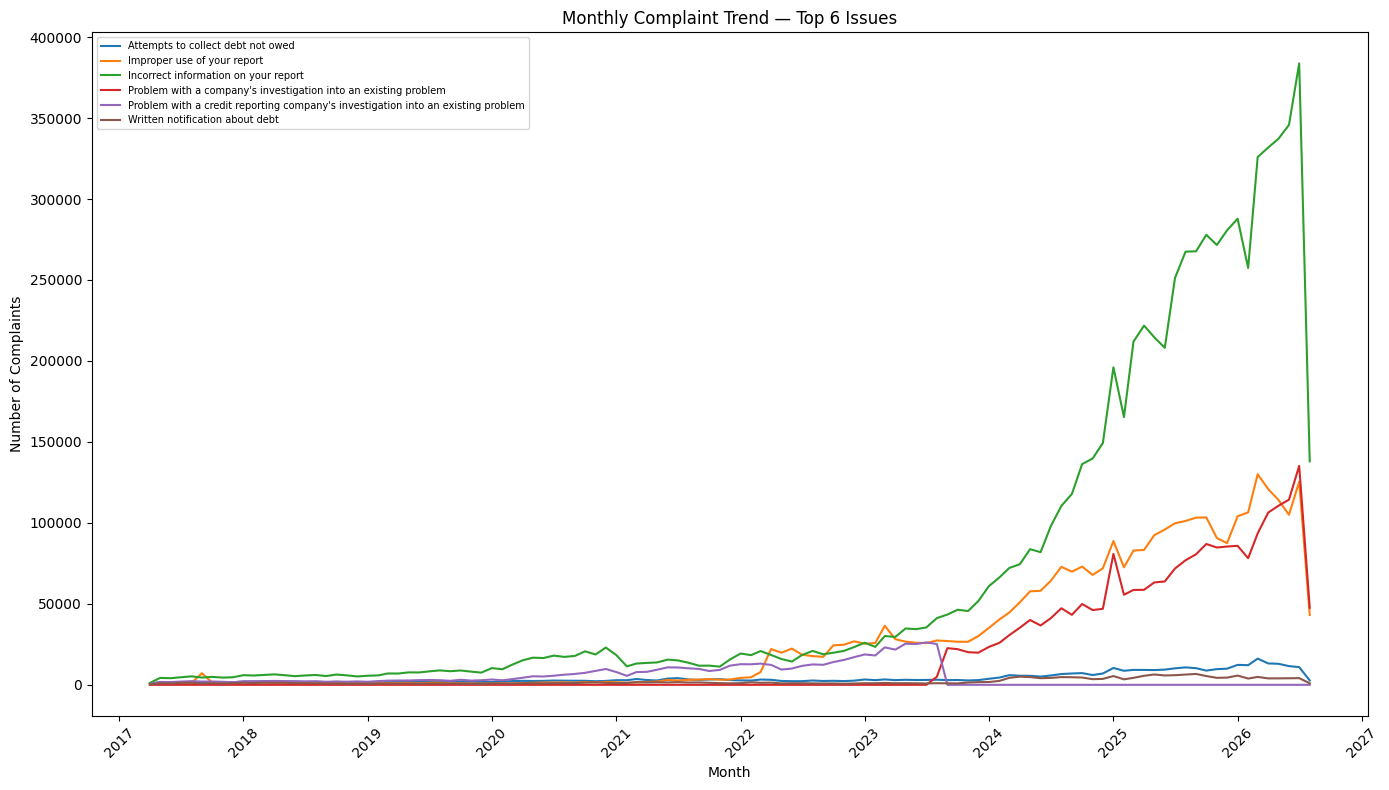


TREND SIGNIFICANCE TEST — Issues (Linear Regression on Monthly Counts)
                                                                           Issue  Slope (complaints/month)  R-squared  p-value            Direction
                                            Incorrect information on your report                   2361.57      0.616 < 0.0001           Increasing
                                                     Improper use of your report                    990.48      0.741 < 0.0001           Increasing
                 Problem with a company's investigation into an existing problem                    784.38      0.608 < 0.0001           Increasing
                                               Attempts to collect debt not owed                     81.20      0.639 < 0.0001           Increasing
                                                 Written notification about debt                     38.51      0.542 < 0.0001           Increasing
Problem with a credit reporting company'

In [111]:
# --- Deep EDA — Issue Trends Over Time (no file export) ---
# Same approach as the Product trend analysis, applied to the "Issue" column.

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Aggregate MONTHLY counts per issue across all 86 chunks
issue_month_counts = {}

for file in files:
    chunk = pd.read_csv(file, usecols=["Date received", "Issue"])
    chunk["Date received"] = pd.to_datetime(chunk["Date received"], errors="coerce")
    chunk["Month"] = chunk["Date received"].dt.to_period("M")

    counts = chunk.groupby(["Month", "Issue"]).size()

    for (month, issue), count in counts.items():
        key = (month, issue)
        issue_month_counts[key] = issue_month_counts.get(key, 0) + count

issue_month = (
    pd.Series(issue_month_counts)
    .rename("Complaint Count")
    .reset_index()
)
issue_month.columns = ["Month", "Issue", "Complaint Count"]
issue_month["Month"] = issue_month["Month"].dt.to_timestamp()

# Step 2: Identify top N issues by total volume
total_by_issue = (
    issue_month.groupby("Issue")["Complaint Count"].sum()
    .sort_values(ascending=False)
)
print("Top 10 issues by total volume:\n")
print(total_by_issue.head(10))

TOP_N = 6
top_issues = total_by_issue.head(TOP_N).index.tolist()

# Step 3: Pivot and plot monthly trend for top issues
top_issue_month = (
    issue_month[issue_month["Issue"].isin(top_issues)]
    .pivot(index="Month", columns="Issue", values="Complaint Count")
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(14, 8))
for issue in top_issue_month.columns:
    plt.plot(top_issue_month.index, top_issue_month[issue], label=issue, linewidth=1.5)

plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.title(f"Monthly Complaint Trend — Top {TOP_N} Issues")
plt.legend(loc="upper left", fontsize=7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 4: Trend significance test (linear regression) for each top issue
print("\n" + "=" * 70)
print("TREND SIGNIFICANCE TEST — Issues (Linear Regression on Monthly Counts)")
print("=" * 70)

trend_results = []

for issue in top_issue_month.columns:
    y = top_issue_month[issue].values
    x = range(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    direction = (
        "Increasing" if slope > 0 and p_value < 0.05
        else "Decreasing" if slope < 0 and p_value < 0.05
        else "No significant trend"
    )

    trend_results.append({
        "Issue": issue,
        "Slope (complaints/month)": round(slope, 2),
        "R-squared": round(r_value ** 2, 3),
        "p-value": "< 0.0001" if p_value < 0.0001 else f"{p_value:.4f}",
        "Direction": direction
    })

trend_df = pd.DataFrame(trend_results).sort_values(
    "Slope (complaints/month)", ascending=False
)
print(trend_df.to_string(index=False))

# NOTE: top_issue_month and issue_month remain available in memory for further
# analysis in this notebook session — nothing is written to disk.

Top 10 issues after merging investigation labels:

Issue
Incorrect information on your report                            7528224
Improper use of your report                                     3244508
Problem with investigation into an existing problem (merged)    2737103
Attempts to collect debt not owed                                467825
Written notification about debt                                  226023
Managing an account                                              225880
Took or threatened to take negative or legal action              143000
False statements or representation                               118424
Loan modification,collection,foreclosure                         112294
Trouble during payment process                                   111411
Name: Complaint Count, dtype: int64


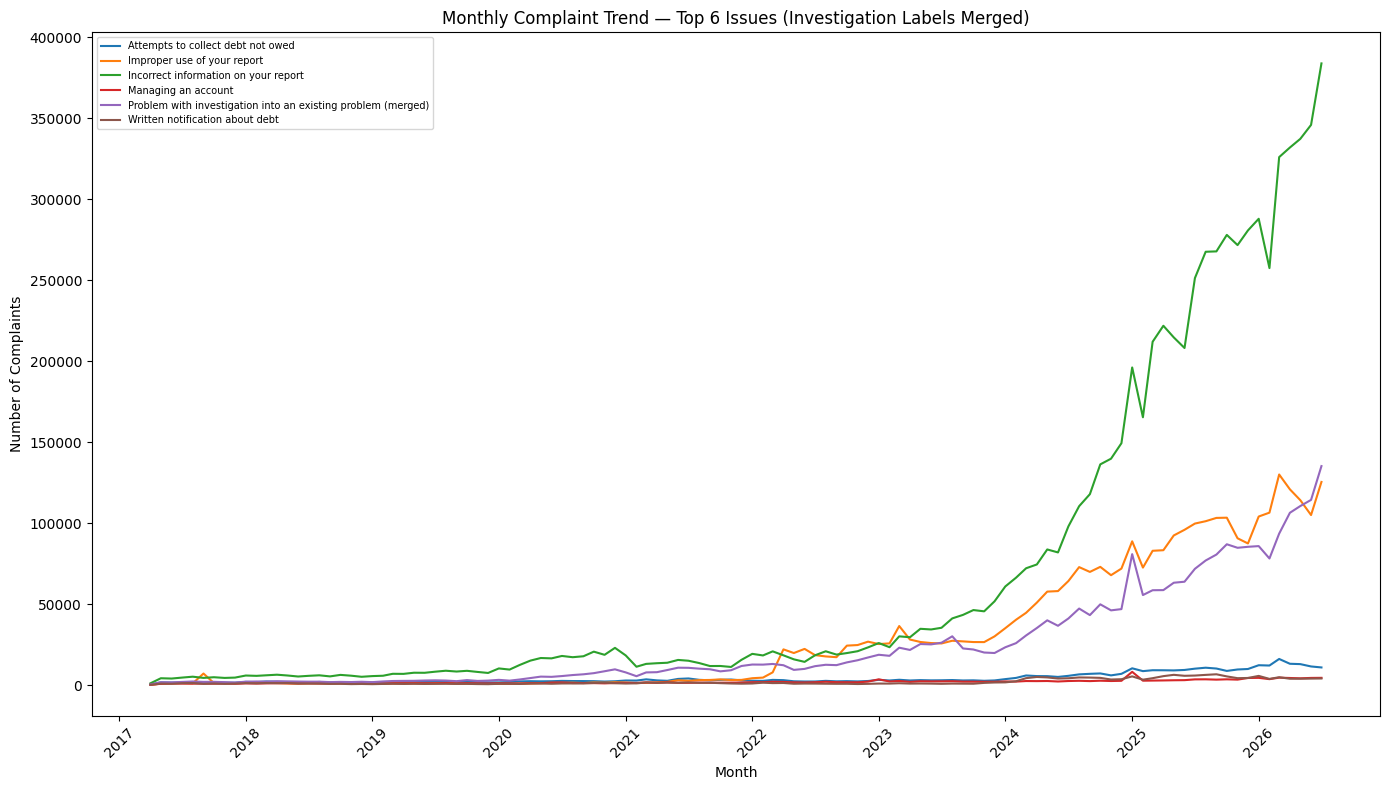


TREND SIGNIFICANCE TEST — Issues (Corrected)
                                                       Issue  Slope (complaints/month)  R-squared  p-value  Direction
                        Incorrect information on your report                   2391.53      0.618 < 0.0001 Increasing
                                 Improper use of your report                   1010.49      0.751 < 0.0001 Increasing
Problem with investigation into an existing problem (merged)                    791.24      0.708 < 0.0001 Increasing
                           Attempts to collect debt not owed                     84.09      0.669 < 0.0001 Increasing
                             Written notification about debt                     40.06      0.573 < 0.0001 Increasing
                                         Managing an account                     29.56      0.693 < 0.0001 Increasing


In [112]:
# --- Fix: Merge the "investigation into an existing problem" issue label transition (2023) ---
# Problem: CFPB renamed
#   "Problem with a credit reporting company's investigation into an existing problem"
# to
#   "Problem with a company's investigation into an existing problem"
# around 2023. These are the SAME issue, not two different ones.
# NOTE: "Incorrect information on your report" and "Improper use of your report"
# are genuinely different issues and are NOT merged.

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Define the merge — only for the investigation-related pair
def normalize_issue(name):
    if isinstance(name, str) and "investigation into an existing problem" in name.lower():
        return "Problem with investigation into an existing problem (merged)"
    return name

# Step 2: Re-aggregate MONTHLY counts per issue, applying the merge
issue_month_counts = {}

for file in files:
    chunk = pd.read_csv(file, usecols=["Date received", "Issue"])
    chunk["Date received"] = pd.to_datetime(chunk["Date received"], errors="coerce")
    chunk["Month"] = chunk["Date received"].dt.to_period("M")

    # Apply the merge BEFORE grouping
    chunk["Issue"] = chunk["Issue"].apply(normalize_issue)

    counts = chunk.groupby(["Month", "Issue"]).size()

    for (month, issue), count in counts.items():
        key = (month, issue)
        issue_month_counts[key] = issue_month_counts.get(key, 0) + count

issue_month = (
    pd.Series(issue_month_counts)
    .rename("Complaint Count")
    .reset_index()
)
issue_month.columns = ["Month", "Issue", "Complaint Count"]
issue_month["Month"] = issue_month["Month"].dt.to_timestamp()

# Step 3: Drop the likely-incomplete final month (same fix as your monthly series)
last_month = issue_month["Month"].max()
issue_month = issue_month[issue_month["Month"] < last_month]

# Step 4: Recompute top 6 issues AFTER merging
total_by_issue = (
    issue_month.groupby("Issue")["Complaint Count"].sum()
    .sort_values(ascending=False)
)
print("Top 10 issues after merging investigation labels:\n")
print(total_by_issue.head(10))

TOP_N = 6
top_issues_merged = total_by_issue.head(TOP_N).index.tolist()

# Step 5: Pivot and plot
top_issue_month_merged = (
    issue_month[issue_month["Issue"].isin(top_issues_merged)]
    .pivot(index="Month", columns="Issue", values="Complaint Count")
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(14, 8))
for issue in top_issue_month_merged.columns:
    plt.plot(top_issue_month_merged.index, top_issue_month_merged[issue],
              label=issue, linewidth=1.5)

plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.title(f"Monthly Complaint Trend — Top {TOP_N} Issues (Investigation Labels Merged)")
plt.legend(loc="upper left", fontsize=7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 6: Re-run trend significance test on corrected data
print("\n" + "=" * 70)
print("TREND SIGNIFICANCE TEST — Issues (Corrected)")
print("=" * 70)

trend_results = []

for issue in top_issue_month_merged.columns:
    y = top_issue_month_merged[issue].values
    x = range(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    direction = (
        "Increasing" if slope > 0 and p_value < 0.05
        else "Decreasing" if slope < 0 and p_value < 0.05
        else "No significant trend"
    )

    trend_results.append({
        "Issue": issue,
        "Slope (complaints/month)": round(slope, 2),
        "R-squared": round(r_value ** 2, 3),
        "p-value": "< 0.0001" if p_value < 0.0001 else f"{p_value:.4f}",
        "Direction": direction
    })

trend_df = pd.DataFrame(trend_results).sort_values(
    "Slope (complaints/month)", ascending=False
)
print(trend_df.to_string(index=False))

In [113]:
# Sub-issue Trend 

Top 10 sub-issues by total volume:

Sub-issue
Information belongs to someone else                         4925867
Reporting company used your report improperly               2410184
Their investigation did not fix an error on your report     1494747
Account information incorrect                               1281079
Investigation took more than 30 days                         911464
Credit inquiries on your report that you don't recognize     818184
Account status incorrect                                     752198
Personal information incorrect                               334955
Debt is not yours                                            261546
Was not notified of investigation status or results          222077
Name: Complaint Count, dtype: int64


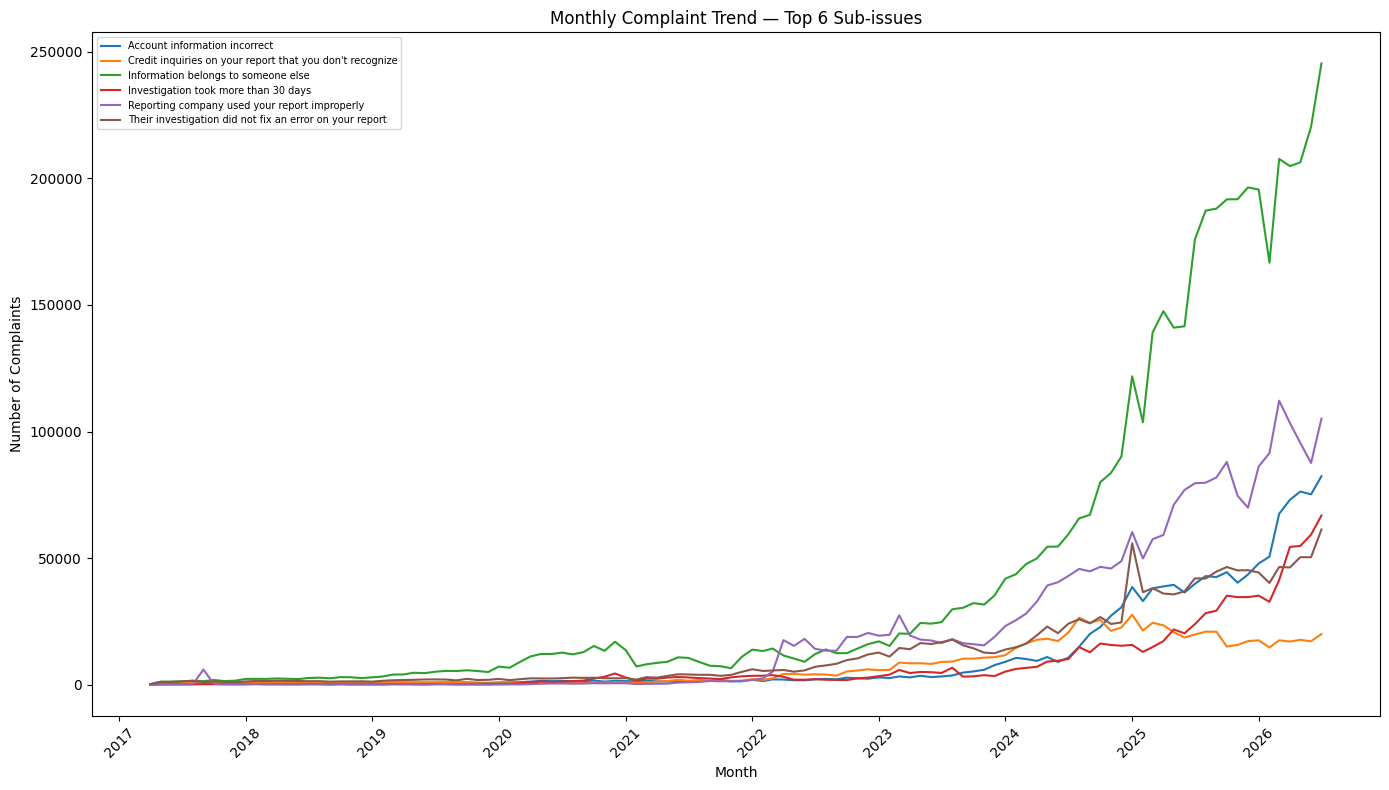


TREND SIGNIFICANCE TEST — Sub-issues (Linear Regression on Monthly Counts)
                                               Sub-issue  Slope (complaints/month)  R-squared  p-value  Direction
                     Information belongs to someone else                   1575.76      0.621 < 0.0001 Increasing
           Reporting company used your report improperly                    787.86      0.709 < 0.0001 Increasing
                           Account information incorrect                    438.46      0.542 < 0.0001 Increasing
 Their investigation did not fix an error on your report                    420.69      0.742 < 0.0001 Increasing
                    Investigation took more than 30 days                    304.69      0.533 < 0.0001 Increasing
Credit inquiries on your report that you don't recognize                    218.48      0.736 < 0.0001 Increasing


In [114]:
# --- Deep EDA — Sub-Issue Trends Over Time ---
# Same approach as Product and Issue trend analysis, applied to "Sub-issue".

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Aggregate MONTHLY counts per sub-issue across all 86 chunks
subissue_month_counts = {}

for file in files:
    chunk = pd.read_csv(file, usecols=["Date received", "Sub-issue"])
    chunk["Date received"] = pd.to_datetime(chunk["Date received"], errors="coerce")
    chunk["Month"] = chunk["Date received"].dt.to_period("M")

    counts = chunk.groupby(["Month", "Sub-issue"], dropna=False).size()

    for (month, subissue), count in counts.items():
        key = (month, subissue)
        subissue_month_counts[key] = subissue_month_counts.get(key, 0) + count

subissue_month = (
    pd.Series(subissue_month_counts)
    .rename("Complaint Count")
    .reset_index()
)
subissue_month.columns = ["Month", "Sub-issue", "Complaint Count"]
subissue_month["Month"] = subissue_month["Month"].dt.to_timestamp()

# Drop rows where Sub-issue is missing (NaN) -- not a real category to trend
subissue_month = subissue_month[subissue_month["Sub-issue"].notna()]

# Step 2: Drop the likely-incomplete final month (same fix as Product/Issue)
last_month = subissue_month["Month"].max()
subissue_month = subissue_month[subissue_month["Month"] < last_month]

# Step 3: Identify top N sub-issues by total volume
total_by_subissue = (
    subissue_month.groupby("Sub-issue")["Complaint Count"].sum()
    .sort_values(ascending=False)
)
print("Top 10 sub-issues by total volume:\n")
print(total_by_subissue.head(10))

TOP_N = 6
top_subissues = total_by_subissue.head(TOP_N).index.tolist()

# Step 4: Pivot and plot monthly trend for top sub-issues
top_subissue_month = (
    subissue_month[subissue_month["Sub-issue"].isin(top_subissues)]
    .pivot(index="Month", columns="Sub-issue", values="Complaint Count")
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(14, 8))
for subissue in top_subissue_month.columns:
    plt.plot(top_subissue_month.index, top_subissue_month[subissue],
              label=subissue, linewidth=1.5)

plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.title(f"Monthly Complaint Trend — Top {TOP_N} Sub-issues")
plt.legend(loc="upper left", fontsize=7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 5: Trend significance test (linear regression) for each top sub-issue
print("\n" + "=" * 70)
print("TREND SIGNIFICANCE TEST — Sub-issues (Linear Regression on Monthly Counts)")
print("=" * 70)

trend_results = []

for subissue in top_subissue_month.columns:
    y = top_subissue_month[subissue].values
    x = range(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    direction = (
        "Increasing" if slope > 0 and p_value < 0.05
        else "Decreasing" if slope < 0 and p_value < 0.05
        else "No significant trend"
    )

    trend_results.append({
        "Sub-issue": subissue,
        "Slope (complaints/month)": round(slope, 2),
        "R-squared": round(r_value ** 2, 3),
        "p-value": "< 0.0001" if p_value < 0.0001 else f"{p_value:.4f}",
        "Direction": direction
    })

trend_df = pd.DataFrame(trend_results).sort_values(
    "Slope (complaints/month)", ascending=False
)
print(trend_df.to_string(index=False))

# Nothing written to disk -- subissue_month, top_subissue_month, trend_df
# remain available in memory for further analysis.

In [115]:
# Companey Level Trend Analysis

Top 15 companies by total volume:

Company
TRANSUNION INTERMEDIATE HOLDINGS, INC.    4576276
EQUIFAX, INC.                             4478273
Experian Information Solutions Inc.       4039208
BANK OF AMERICA, NATIONAL ASSOCIATION      184225
JPMORGAN CHASE & CO.                       173093
WELLS FARGO & COMPANY                      172748
CAPITAL ONE FINANCIAL CORPORATION          168170
CITIBANK, N.A.                             139257
SYNCHRONY FINANCIAL                         82149
Resurgent Capital Services L.P.             69393
Block, Inc.                                 69040
ENCORE CAPITAL GROUP INC.                   64905
Portfolio Recovery Associates, LLC          63549
LEXISNEXIS                                  62769
AMERICAN EXPRESS COMPANY                    58807
Name: Complaint Count, dtype: int64


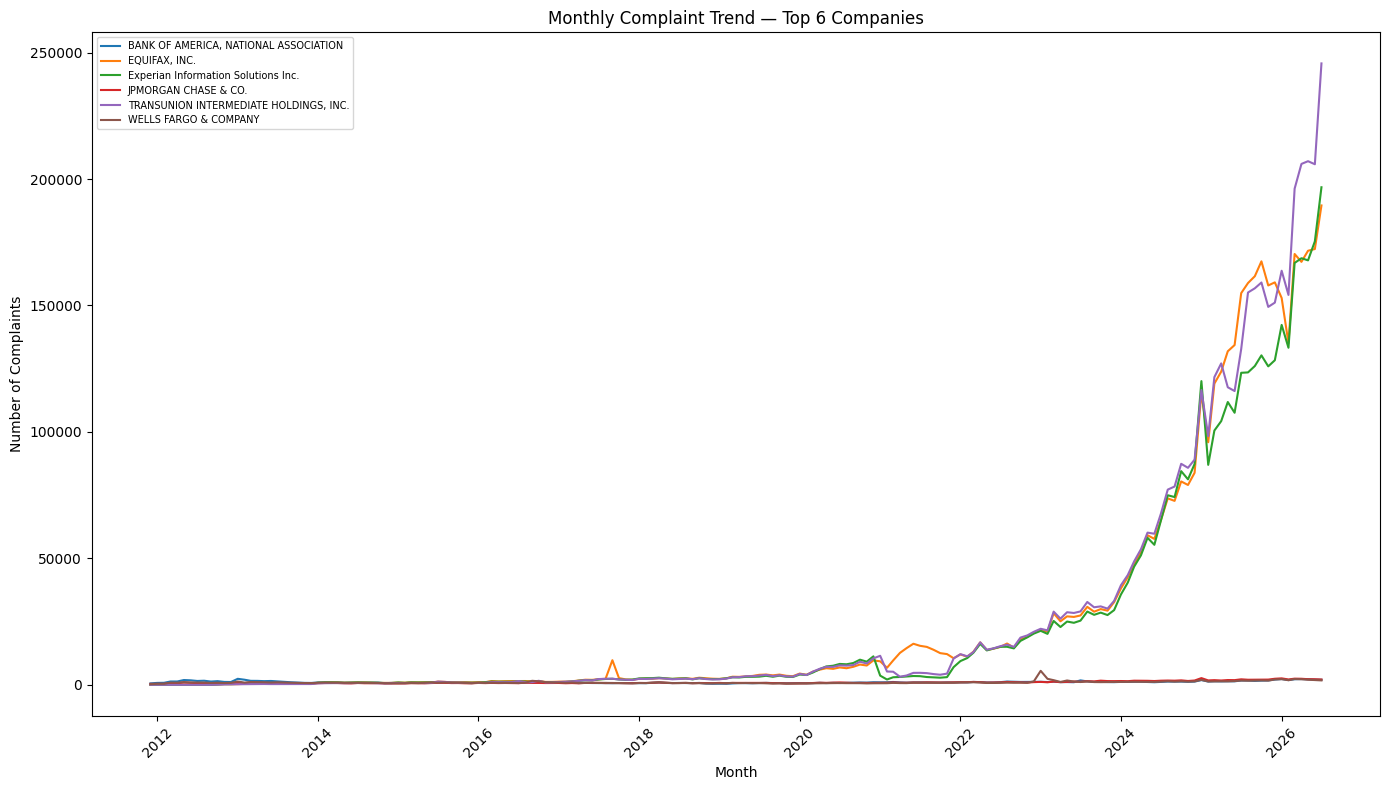


TREND SIGNIFICANCE TEST — Companies (Linear Regression on Monthly Counts)
                               Company  Slope (complaints/month)  R-squared  p-value  Direction
TRANSUNION INTERMEDIATE HOLDINGS, INC.                    691.42      0.487 < 0.0001 Increasing
                         EQUIFAX, INC.                    659.89      0.513 < 0.0001 Increasing
   Experian Information Solutions Inc.                    601.22      0.506 < 0.0001 Increasing
                  JPMORGAN CHASE & CO.                      7.95      0.658 < 0.0001 Increasing
                 WELLS FARGO & COMPANY                      5.10      0.241 < 0.0001 Increasing
 BANK OF AMERICA, NATIONAL ASSOCIATION                      2.66      0.113 < 0.0001 Increasing

BIG 3 CREDIT BUREAUS — Total Volume Check

EQUIFAX:
Company
EQUIFAX, INC.    4478273
Name: Complaint Count, dtype: int64

TRANSUNION:
Company
TRANSUNION INTERMEDIATE HOLDINGS, INC.    4576276
Name: Complaint Count, dtype: int64

EXPERIAN:
Company
Exper

In [116]:
# --- Deep EDA — Company Trends Over Time ---
# Same approach as Product/Issue/Sub-issue trend analysis, applied to "Company".

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Aggregate MONTHLY counts per company across all 86 chunks
company_month_counts = {}

for file in files:
    chunk = pd.read_csv(file, usecols=["Date received", "Company"])
    chunk["Date received"] = pd.to_datetime(chunk["Date received"], errors="coerce")
    chunk["Month"] = chunk["Date received"].dt.to_period("M")

    counts = chunk.groupby(["Month", "Company"]).size()

    for (month, company), count in counts.items():
        key = (month, company)
        company_month_counts[key] = company_month_counts.get(key, 0) + count

company_month = (
    pd.Series(company_month_counts)
    .rename("Complaint Count")
    .reset_index()
)
company_month.columns = ["Month", "Company", "Complaint Count"]
company_month["Month"] = company_month["Month"].dt.to_timestamp()

# Step 2: Drop the likely-incomplete final month
last_month = company_month["Month"].max()
company_month = company_month[company_month["Month"] < last_month]

# Step 3: Identify top N companies by total volume
total_by_company = (
    company_month.groupby("Company")["Complaint Count"].sum()
    .sort_values(ascending=False)
)
print("Top 15 companies by total volume:\n")
print(total_by_company.head(15))

TOP_N = 6
top_companies = total_by_company.head(TOP_N).index.tolist()

# Step 4: Pivot and plot monthly trend for top companies
top_company_month = (
    company_month[company_month["Company"].isin(top_companies)]
    .pivot(index="Month", columns="Company", values="Complaint Count")
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(14, 8))
for company in top_company_month.columns:
    plt.plot(top_company_month.index, top_company_month[company],
              label=company, linewidth=1.5)

plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.title(f"Monthly Complaint Trend — Top {TOP_N} Companies")
plt.legend(loc="upper left", fontsize=7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 5: Trend significance test (linear regression) for each top company
print("\n" + "=" * 70)
print("TREND SIGNIFICANCE TEST — Companies (Linear Regression on Monthly Counts)")
print("=" * 70)

trend_results = []

for company in top_company_month.columns:
    y = top_company_month[company].values
    x = range(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    direction = (
        "Increasing" if slope > 0 and p_value < 0.05
        else "Decreasing" if slope < 0 and p_value < 0.05
        else "No significant trend"
    )

    trend_results.append({
        "Company": company,
        "Slope (complaints/month)": round(slope, 2),
        "R-squared": round(r_value ** 2, 3),
        "p-value": "< 0.0001" if p_value < 0.0001 else f"{p_value:.4f}",
        "Direction": direction
    })

trend_df = pd.DataFrame(trend_results).sort_values(
    "Slope (complaints/month)", ascending=False
)
print(trend_df.to_string(index=False))

# Step 6: Since credit reporting dominates, check the "Big 3" credit bureaus specifically
print("\n" + "=" * 70)
print("BIG 3 CREDIT BUREAUS — Total Volume Check")
print("=" * 70)

bureau_keywords = ["EQUIFAX", "TRANSUNION", "EXPERIAN"]
for keyword in bureau_keywords:
    matches = total_by_company[total_by_company.index.str.contains(keyword, case=False, na=False)]
    print(f"\n{keyword}:")
    print(matches)

# Nothing written to disk -- company_month, top_company_month, trend_df
# remain available in memory for further analysis.

In [117]:
# State Level Analysis 

Top 15 states by total volume:

State
FL    2307588
TX    2305456
CA    1683207
GA    1246932
NY     984882
IL     723214
PA     664908
NC     578658
NJ     540381
MD     416561
AL     403571
SC     371327
LA     371250
MI     364626
OH     362308
Name: Complaint Count, dtype: int64

Total distinct state/territory codes: 63


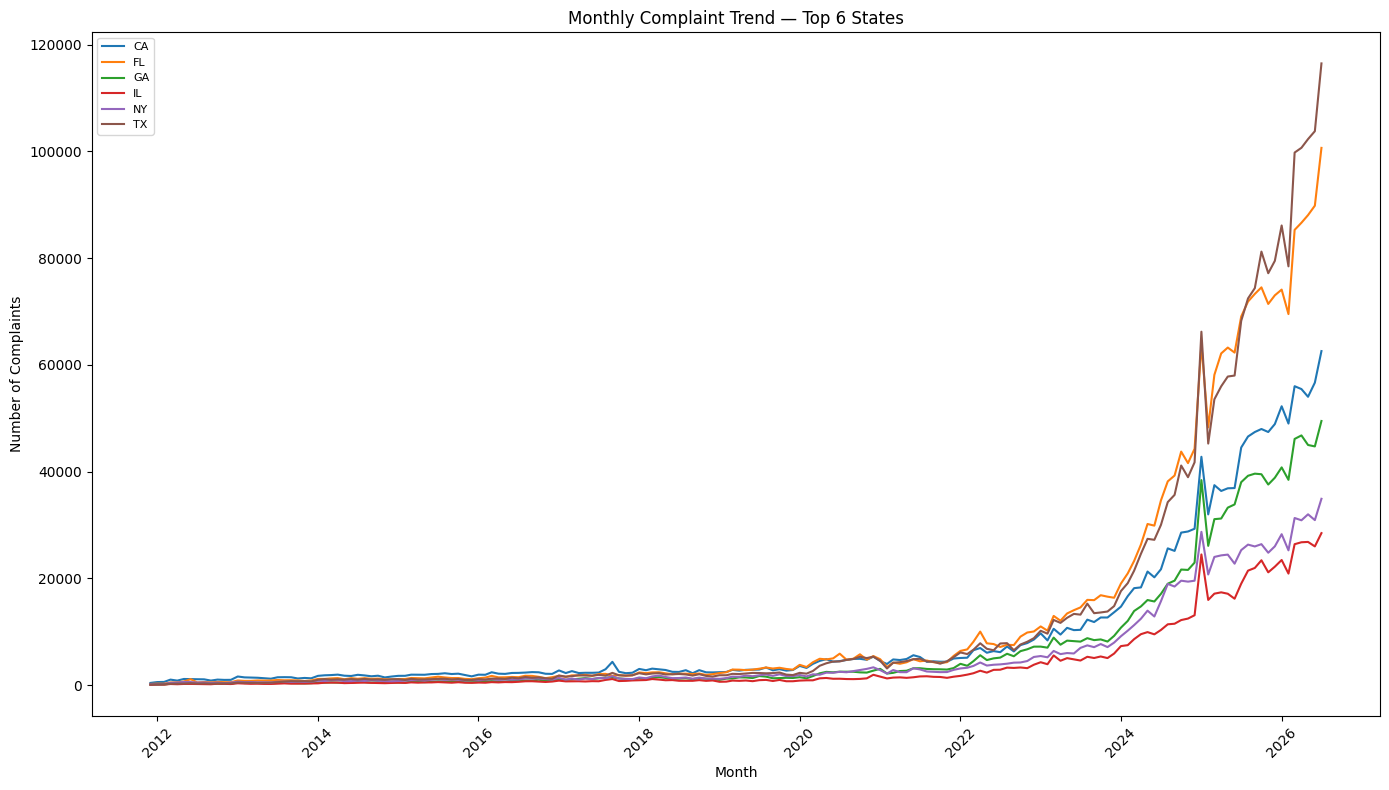


TREND SIGNIFICANCE TEST — States (Linear Regression on Monthly Counts)
State  Slope (complaints/month)  R-squared  p-value  Direction
   TX                    332.71      0.472 < 0.0001 Increasing
   FL                    321.00      0.512 < 0.0001 Increasing
   CA                    207.03      0.537 < 0.0001 Increasing
   GA                    172.83      0.530 < 0.0001 Increasing
   NY                    124.60      0.562 < 0.0001 Increasing
   IL                     97.83      0.527 < 0.0001 Increasing

TOP STATES — SHARE OF TOTAL COMPLAINTS
State
FL    13.71
TX    13.69
CA    10.00
GA     7.41
NY     5.85
IL     4.30
PA     3.95
NC     3.44
NJ     3.21
MD     2.47
Name: Complaint Count, dtype: float64


In [118]:
# --- Deep EDA — State Trends Over Time ---
# Same approach as Product/Issue/Sub-issue/Company trend analysis, applied to "State".

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Aggregate MONTHLY counts per state across all 86 chunks
state_month_counts = {}

for file in files:
    chunk = pd.read_csv(file, usecols=["Date received", "State"])
    chunk["Date received"] = pd.to_datetime(chunk["Date received"], errors="coerce")
    chunk["Month"] = chunk["Date received"].dt.to_period("M")

    counts = chunk.groupby(["Month", "State"], dropna=False).size()

    for (month, state), count in counts.items():
        key = (month, state)
        state_month_counts[key] = state_month_counts.get(key, 0) + count

state_month = (
    pd.Series(state_month_counts)
    .rename("Complaint Count")
    .reset_index()
)
state_month.columns = ["Month", "State", "Complaint Count"]
state_month["Month"] = state_month["Month"].dt.to_timestamp()

# Drop rows where State is missing (NaN) -- not a real category to trend
state_month = state_month[state_month["State"].notna()]

# Step 2: Drop the likely-incomplete final month
last_month = state_month["Month"].max()
state_month = state_month[state_month["Month"] < last_month]

# Step 3: Identify top N states by total volume
total_by_state = (
    state_month.groupby("State")["Complaint Count"].sum()
    .sort_values(ascending=False)
)
print("Top 15 states by total volume:\n")
print(total_by_state.head(15))
print(f"\nTotal distinct state/territory codes: {total_by_state.shape[0]}")

TOP_N = 6
top_states = total_by_state.head(TOP_N).index.tolist()

# Step 4: Pivot and plot monthly trend for top states
top_state_month = (
    state_month[state_month["State"].isin(top_states)]
    .pivot(index="Month", columns="State", values="Complaint Count")
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(14, 8))
for state in top_state_month.columns:
    plt.plot(top_state_month.index, top_state_month[state],
              label=state, linewidth=1.5)

plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.title(f"Monthly Complaint Trend — Top {TOP_N} States")
plt.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 5: Trend significance test (linear regression) for each top state
print("\n" + "=" * 70)
print("TREND SIGNIFICANCE TEST — States (Linear Regression on Monthly Counts)")
print("=" * 70)

trend_results = []

for state in top_state_month.columns:
    y = top_state_month[state].values
    x = range(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    direction = (
        "Increasing" if slope > 0 and p_value < 0.05
        else "Decreasing" if slope < 0 and p_value < 0.05
        else "No significant trend"
    )

    trend_results.append({
        "State": state,
        "Slope (complaints/month)": round(slope, 2),
        "R-squared": round(r_value ** 2, 3),
        "p-value": "< 0.0001" if p_value < 0.0001 else f"{p_value:.4f}",
        "Direction": direction
    })

trend_df = pd.DataFrame(trend_results).sort_values(
    "Slope (complaints/month)", ascending=False
)
print(trend_df.to_string(index=False))

# Step 6: Per-capita-style sanity check -- top states by volume are often
# just the most populous states. Print share of total to contextualize.
print("\n" + "=" * 70)
print("TOP STATES — SHARE OF TOTAL COMPLAINTS")
print("=" * 70)
total_all = total_by_state.sum()
share = (total_by_state.head(10) / total_all * 100).round(2)
print(share)

# Nothing written to disk -- state_month, top_state_month, trend_df
# remain available in memory for further analysis.